## Executive Summary
This project analyzes Cyclistic’s bike‑share trip data from 2016 to 2025 to understand how annual members and casual riders differ in their usage patterns and how these behaviors have evolved over time. Historically, annual members have shown consistent commuting‑oriented behavior—weekday usage, peak travel hours, shorter trip durations, and evenly distributed station activity—while casual riders have exhibited leisure‑focused patterns with longer rides and concentrated usage near tourist destinations.  
  
However, starting in 2020, casual rider behavior changed dramatically. Their weekday usage increased, trip durations shortened, and station usage diversified, indicating that many casual riders began using Cyclistic for routine mobility rather than occasional recreation. Casual ridership also grew significantly faster than member ridership during this period.  
  
These shifts present a strong opportunity for Cyclistic: a large portion of casual riders now behave similarly to annual members and may be highly receptive to targeted membership‑conversion campaigns. The insights from this analysis provide a data‑driven foundation for designing marketing strategies that increase annual memberships and support Cyclistic’s long‑term growth.

---

## Background Information 
Cyclistic, a leading bike-share program in Chicago, has grown significantly since its launch in 2016, now operating more than 5,800 bicycles across nearly 700 docking stations. Its inclusive fleet—featuring traditional bikes as well as reclining, hand tricycle, and cargo options—serves a diverse customer base that rides for both leisure and daily commuting. Historically, Cyclistic’s marketing strategy has focused on broad awareness and flexible pricing plans, offering single-ride passes, full-day passes, and annual memberships. While this approach has expanded ridership, internal financial analysis shows that __annual members generate substantially higher long-term profitability compared to casual riders__.

## Stretigic Goal of Marketing 
Recognizing this opportunity, Lily Moreno, Director of Marketing, has set a strategic goal to __increase annual memberships by converting existing casual riders.__ Casual riders already know the Cyclistic brand and actively use its services, making them a promising segment for targeted marketing interventions. To design an effective conversion strategy, the marketing analytics team must first understand how casual riders and annual members differ in their usage patterns, motivations, and engagement behaviors.

## Key Question
### How do annual members and casual riders use Cyclistic bikes differently?

This project analyzes Cyclistic’s historical trip data to uncover behavioral trends, usage frequency, ride duration, temporal patterns, and station preferences across rider types. These insights will inform the development of a data-driven marketing strategy aimed at converting casual riders into committed annual members. These findings will directly influence Cyclistic’s future marketing direction and will serve as the evidence base for executive approval of the proposed membership growth strategy.

## Considerations to analysis
* Product Context - Bicycle usage is highly seasonal and strongly influenced by weather conditions.
* Location Context - Chicago experiences harsh winters, which significantly affect bike‑share activity and must be considered when interpreting trends.
* Time Context - The dataset spans 2016 to the present, a period that includes the COVID‑19 pandemic. Pandemic‑related behavioral changes must be accounted for in the analysis.
* Analytical Focus - Because the business goal is to convert casual riders into annual members, the analysis centers on comparing these two groups.

## Methology & Skills
The goal of this project is to identify patterns and trends by analyzing large‑scale historical trip data. Python is the primary tool for data manipulation, cleaning, and visualization due to its efficiency and flexibility with diverse data formats. Excel is used for initial inspection and manual preprocessing of complex or inconsistent data.

Key tools and libraries include:
* Python libraries: NumPy, pandas, datetime, openpyxl
* Visualization: Matplotlib, seaborn, IPython
* Excel: Manual review and preprocessing of raw CSV structures with formulas and functions such as vlookup
  
These tools support the extraction, cleaning, transformation, and visualization of Cyclistic’s trip data, enabling a comprehensive and reliable analysis.

In [1]:
"""
These libraries are used all of the project.
"""
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML, display
#from tabulate import tabulate

def color_positive(val):
    if val > 0:
        return 'color: #CC5500; font-weight: bold' 
    return ''
def format_positive(val):
    if val > 0:
        return f'{val:.1%}' 
    return '0'

## 1. Prepare and Process

### A. Data source 
Cyclistic’s historical trip data is used to analyze rider behavior and identify long‑term trends. The dataset contains the past 12 months of trip records and is publicly available through Motivate International Inc. Although the dataset uses different naming conventions because Cyclistic is fictional, it is fully suitable for this case study.  
  
Due to strict data‑privacy rules, personally identifiable information cannot be used. Therefore, this project relies exclusively on trip‑level bicycle usage data and does not link rides to individual customers.  

[Download the previous 12 months of Cyclistic trip data here.](https://divvy-tripdata.s3.amazonaws.com/index.html) ([license](https://divvybikes.com/data-license-agreement).) 

### B. Preparation for processing

The raw trip data consists of more than 100 CSV files with varying formats and column structures. These files are organized by year (2013–2026) and stored either monthly or quarterly. Each file contains hundreds of thousands to millions of records, making it impractical to load all data into memory at once. To ensure efficient processing, the data is handled year‑by‑year and quarter‑by‑quarter.

The overall workflow includes:

* Loading each CSV file and exporting column names and sample rows to Excel for classification
* Performing manual inspection in Excel to understand structural differences
* Creating functions to extract, clean, and transform data
* Building a metadata file to standardize loading of different CSV formats into yearly and quarterly DataFrames

#### 1. load csv files and export to excel
Each CSV file is loaded, and its column names and sample data are exported to Excel. This step helps identify differences in structure, naming conventions, and formatting across years.

In [2]:
import os

# Load each data csv file into DataFrame and extract usefull data such as file info, datatypes and sampledata.

columnnames = []
datatypes = []
datasample = []

# Read all files in the input dataset and append full filename, filename, colum names, data types and data sample to the lists.
# It take quite a time and if all the files loaded into one dataframe memory issue occurs.
for dirname, _, filenames in os.walk('/kaggle/input/datasets/canadawoodpecker/divvy-trips'):
    for filename in filenames:
        filename_str = filename.split('.')
        if filename_str[-1] == 'csv':
            print(filename, end="")
            fullfilename = os.path.join(dirname, filename)
            #print(fullfilename)
            df = pd.read_csv(fullfilename)
            columnnames.append([fullfilename, filename]+ df.columns.values.tolist())
            datatypes.append([fullfilename, filename] + df.dtypes.tolist())
            datasample.append([fullfilename, filename] + df.loc[1, :].values.tolist())
            print("!", end=" ")
            #print(df.loc[1, :].values)
            #df_info.loc[len(df_info)] = [df.columns]
print("")
print("Done!")

202101-divvy-tripdata.csv! 202504-divvy-tripdata.csv! 202302-divvy-tripdata.csv! 202303-divvy-tripdata.csv! 202012-divvy-tripdata.csv! 202505-divvy-tripdata.csv! 202404-divvy-tripdata.csv! Divvy_Stations_2016_Q4.csv! Divvy_Stations_2016_Q3.csv! Divvy_Trips_2016_Q3.csv! Divvy_Trips_2016_Q4.csv! 202004-divvy-tripdata.csv! 202312-divvy-tripdata.csv! 202405-divvy-tripdata.csv! 202604-divvy-tripdata.csv! 202104-divvy-tripdata.csv! 202508-divvy-tripdata.csv! 202204-divvy-tripdata.csv! 202310-divvy-tripdata.csv! 202308-divvy-tripdata.csv! 202507-divvy-tripdata.csv! 202006-divvy-tripdata.csv! 202301-divvy-tripdata.csv! 202401-divvy-tripdata.csv! Divvy_Trips_2018_Q1.csv! 202009-divvy-tripdata.csv! 202011-divvy-tripdata.csv! Divvy_Trips_2013.csv

/tmp/ipykernel_16/1199838218.py:18: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fullfilename)


! Divvy_Stations_2013.csv! Divvy_Trips_2018_Q3.csv! 202408-divvy-tripdata.csv! 202306-divvy-tripdata.csv! 202208-divvy-tripdata.csv! 202202-divvy-tripdata.csv! 202106-divvy-tripdata.csv! Divvy_Trips_2019_Q3.csv! 202008-divvy-tripdata.csv! 202506-divvy-tripdata.csv! 202105-divvy-tripdata.csv! 202406-divvy-tripdata.csv! Divvy_Trips_2019_Q2.csv! 202201-divvy-tripdata.csv! 202203-divvy-tripdata.csv! 202206-divvy-tripdata.csv! 202510-divvy-tripdata.csv! 202407-divvy-tripdata.csv! 202107-divvy-tripdata.csv! 202502-divvy-tripdata.csv! 202209-divvy-publictripdata.csv! 202411-divvy-tripdata.csv! 202007-divvy-tripdata.csv! Divvy_Trips_2015_09.csv! Divvy_Trips_2015_07.csv! Divvy_Trips_2015_08.csv! Divvy_Trips_2015_Q4.csv! Divvy_Trips_2018_Q2.csv! Divvy_Trips_2019_Q4.csv! Divvy_Trips_2017_Q2.csv! Divvy_Stations_2017_Q1Q2.csv! Divvy_Trips_2017_Q1.csv! 202412-divvy-tripdata.csv! 202111-divvy-tripdata.csv! 202512-divvy-tripdata.csv! Divvy_Stations_2015.csv! Divvy_Trips_2015-Q2.csv! Divvy_Trips_2015-Q

In [3]:
from openpyxl import Workbook
from pathlib import Path

# Save the data loaded previous cell into ouput_report excel file to closer look.
# Workbook consists of three worksheets, column names sheet, data types sheet and data sample sheet.
wb = Workbook()
ws = wb.active
ws.title = "columnnames"

header = ["filename"] + ["col" + str(x) for x in range(1,len(columnnames[0])-1)] 
ws.append(header)
for line in columnnames:
    ws.append(line[1:])

ws = wb.create_sheet(title = "datatypes")
ws.append(header)
for line in datatypes:
    ws.append(str(t) for t in line[1:])

ws = wb.create_sheet(title = "datasample")
ws.append(header)
for line in datasample:
    ws.append(line[1:])

# Save it as output_report.xlsx into output area where files are olny exists the session is on.
wb.save("/kaggle/working/output_report.xlsx")
print("File Generated!")

File Generated!


### 2. Manual Review in Excel
The data files vary significantly depending on the year or quarter. For example:  
  
* The start time column appears as starttime in older files and started_at in newer ones
* Date formats differ (e.g., 6/30/2014 23:55 vs. 2020‑04‑17 17:08:54)
* User type classification changed from Customer/Subscriber (before 2020) to casual/member (from 2020)

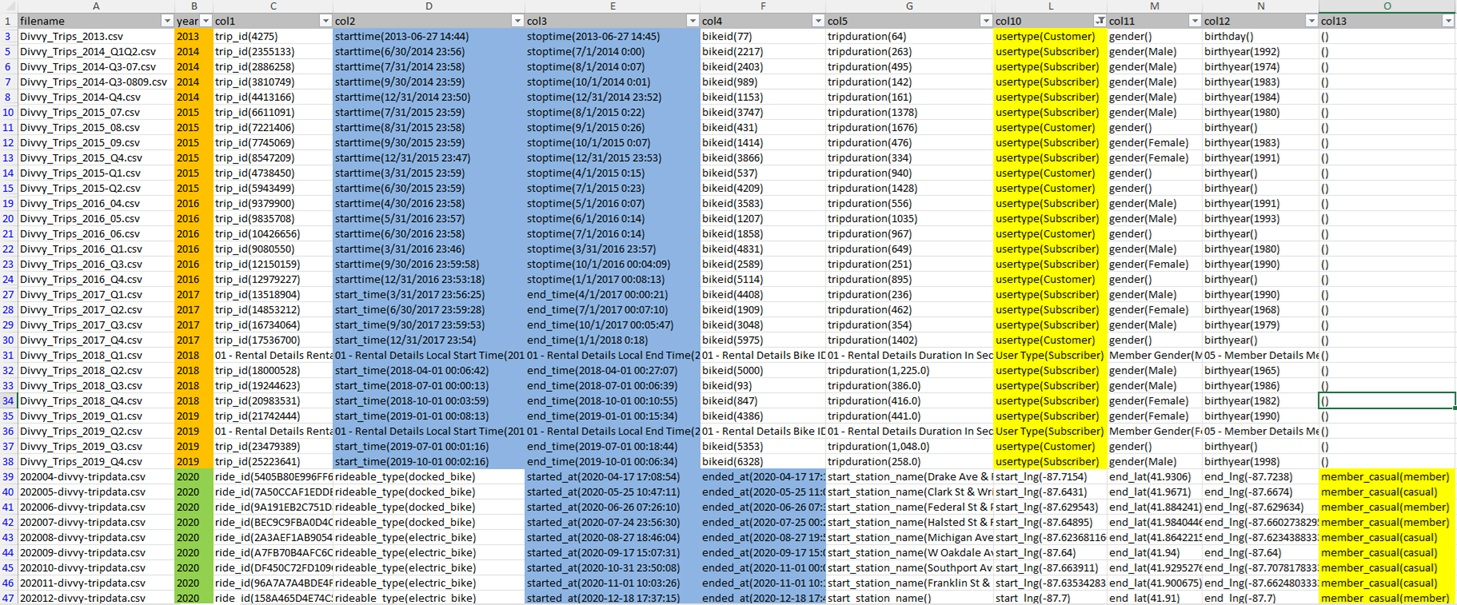

#### 3. Create Functions for Extraction, Cleaning, and Transformation
Custom functions are developed to read, clean, and standardize the data. These functions handle:  
  
* Column renaming
* Date/time parsing
* User type normalization
* Trip Duration calculation
* Removal of invalid records

In [4]:
# Create a file dataframe that contains file info.
file_df = pd.DataFrame(columnnames, columns=["fullname"] + header)
file_df.reset_index(inplace=True)
file_df.drop(columns=header[1:], inplace=True)

# remove rows with Stations. These files are not trip data files.
file_df = file_df[~file_df.filename.str.contains('Stations')]

# remove before year 2016. The company seems to be started before 2016 but official loanch was 2016. 
# So the data before 2016 is no suitable data.
file_df = file_df[~file_df.filename.str.contains('2013')]
file_df = file_df[~file_df.filename.str.contains('2014')]
file_df = file_df[~file_df.filename.str.contains('2015')]
file_df = file_df.reset_index(drop=True)

file_df.sample(5)

,index,fullname,filename
43,47,/kaggle/input/datasets/canadawoodpecker/divvy-...,202502-divvy-tripdata.csv
30,34,/kaggle/input/datasets/canadawoodpecker/divvy-...,202106-divvy-tripdata.csv
57,69,/kaggle/input/datasets/canadawoodpecker/divvy-...,202307-divvy-tripdata.csv
21,23,/kaggle/input/datasets/canadawoodpecker/divvy-...,202401-divvy-tripdata.csv
26,30,/kaggle/input/datasets/canadawoodpecker/divvy-...,202408-divvy-tripdata.csv


In [5]:
def check_dtformat(str):
    """
    Temporay function to check suitable format string to convert datetime string to datetime.
    Args:
        str: datetime string to check
    Returns:
        string: proper format string 
    Example:
        >>> check_dtformat('6/30/2014 23:55')
        '%m/%d/%Y %H:%M'
    """
    for fmt in ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S', '%Y-%m-%d %H:%M:%S.%f']:
        try:
            pd.to_datetime(str, format=fmt)
            return fmt
        except ValueError:
            continue
    return 'mixed'

#### 4. Create Metadata File
A metadata file is created to map each CSV file to its correct structure. This allows automated extraction of yearly and quarterly DataFrames regardless of format differences.

In [6]:
# In this code cell, generats a csv file that contains meta data to help loading dataset files easily for the future use.
# As the dataset files will be loaded and treated by year and quater, year and quater info is to be extracted from file name.
# In additon, types and formats column going to be added to transform the different column names in diffenet places with diffenent formats into uniform structure.

years = []
qters = []
types = []
formats = []

for index, row in file_df.iterrows():
    filecore = row['filename'].split('.')[0]
    if filecore[:3] == 'Div':
        filestrs = filecore.split('_')
        year = filestrs[2]
        qter = filestrs[3]
        if year == '2020' : 
            type_s = 'B'
        else:
            type_s = 'A'
        if qter[0] == '0':
            qter = 'Q2'
    else:
        type_s = 'B'
        year = filecore[:4]
        qter = filecore[4:6]
        if qter in ['01', '02', '03']:
            qter = 'Q1'
        elif qter in ['04', '05', '06']:
            qter = 'Q2'
        elif qter in ['07', '08', '09']:
            qter = 'Q3'
        else:
            qter = 'Q4'
    
    types.append(type_s)
    years.append(year)
    qters.append(qter)

    sample = datasample[row['index']]
    
    if type_s == 'A':
        sample_s = sample[3]
    else :
        sample_s = sample[4]
    #formats.append(dateinfer.infer(sample_s))
    formats.append(check_dtformat(sample_s))

file_df['year'] = years
file_df['qter'] = qters
file_df['type'] = types
file_df['format'] = formats

file_df.drop(columns='index', inplace=True)

# the file contains these columns, that are fullname to access real file path, filename(key), 
# yeara and qter for look up file list, type and format to help extract, clean and transform.
file_df.to_csv('/kaggle/working/fileinfo.csv', index=False)

print('file info saved!')
file_df.sample(5)

file info saved!


,fullname,filename,year,qter,type,format
29,/kaggle/input/datasets/canadawoodpecker/divvy-...,202202-divvy-tripdata.csv,2022,Q1,B,%Y-%m-%d %H:%M:%S
18,/kaggle/input/datasets/canadawoodpecker/divvy-...,202507-divvy-tripdata.csv,2025,Q3,B,%Y-%m-%d %H:%M:%S.%f
50,/kaggle/input/datasets/canadawoodpecker/divvy-...,Divvy_Trips_2017_Q1.csv,2017,Q1,A,%m/%d/%Y %H:%M:%S
41,/kaggle/input/datasets/canadawoodpecker/divvy-...,202407-divvy-tripdata.csv,2024,Q3,B,%Y-%m-%d %H:%M:%S.%f
11,/kaggle/input/datasets/canadawoodpecker/divvy-...,202405-divvy-tripdata.csv,2024,Q2,B,%Y-%m-%d %H:%M:%S


### C. Processing 
Cyclistic’s trip data shows substantial structural differences across years, especially around 2020.  
  
Variations include:  
* Monthly vs. quarterly storage intervals
* Column name changes
* Different date formats
* Shifts in user type classification
* Missing or inconsistent values
  
To ensure reliable analysis, the data must be standardized while accounting for these discrepancies.

Key Processing Tasks:
* Storage interval differences: Example: Divvy_Stations_2017_Q4.csv vs. Divvy_Trips_2016_04.csv
* Column name inconsistencies: Example: starttime (pre‑2020) vs. started_at (post‑2020)
* User type changes: Subscriber/Customer → member/casual
* Date format inconsistencies: 4/30/2016 23:58 vs. 2025‑10‑14 08:04:08.663
* Null values: Particularly in from_station_name, increasing to 22% by 2025
* Data errors: Some records show end times earlier than start times
* Data transformations: Ride duration, weekday extraction, hour extraction, etc.

Columns Used for Analysis:
* user_types — casual vs. annual members
* started — start datetime
* stopped — end datetime
* from_station_name — starting station

Columns Excluded:
* gender/birthyear — only available before 2020
* location coordinates — station names provide sufficient insight, This value used for missing data validation for from_station_name.
* bike type — inconsistent and not analytically meaningful

In [7]:
# load meta data csv file into file_df DataFrame.
# This meta data DataFrame will be used to load exact data files and extract into propely.
file_df = pd.read_csv('/kaggle/input/datasets/canadawoodpecker/workingfiles/fileinfo.csv')
file_df.head(5)

,fullname,filename,year,qter,type,format
0,/kaggle/input/datasets/canadawoodpecker/divvy-...,Divvy_Trips_2016_Q1.csv,2016,Q1,A,%m/%d/%Y %H:%M
1,/kaggle/input/datasets/canadawoodpecker/divvy-...,Divvy_Trips_2016_06.csv,2016,Q2,A,%m/%d/%Y %H:%M
2,/kaggle/input/datasets/canadawoodpecker/divvy-...,Divvy_Trips_2016_05.csv,2016,Q2,A,%m/%d/%Y %H:%M
3,/kaggle/input/datasets/canadawoodpecker/divvy-...,Divvy_Trips_2016_04.csv,2016,Q2,A,%m/%d/%Y %H:%M
4,/kaggle/input/datasets/canadawoodpecker/divvy-...,Divvy_Trips_2016_Q3.csv,2016,Q3,A,%m/%d/%Y %H:%M:%S


In [8]:
import datetime

def read_data(read_df, include_from_station_pos = False):
    """
    Function to load all files in read_df DataFrame and verify, clean and transform it.
    Args:
        DataFrame: Pandas DataFrame that contains meta data info
        include_from_station_pos: True if read  from station pos (before 2020 : from station ID, from 2020 : from station lattitude)
    Returns:
        DataFrame: The DataFrame that is processed
    Example:
        >>> read_data(file_df[(file_df['year'] == year) & (file_df['qter'] == qter)])
    """
    
    starteds = []
    stopeds = []
    user_types = []
    from_station_names = []
    if include_from_station_pos :
        from_station_pos = [] # before 2020 : from station ID, from 2020 : from station lattitude

    # Read meata data file list 
    for index, row in read_df.iterrows():
        #print(row['filename'], row['format'], end="")
        print(row['filename'], end="")
        df = pd.read_csv(row['fullname'])
        if row['type'] == 'A': # for csv files before 2020
            # convert date time string to datetime object
            starteds.extend(pd.to_datetime(df.iloc[:, 1], format=row['format']).to_list())
            stopeds.extend(pd.to_datetime(df.iloc[:, 2], format=row['format']).to_list())

            # changes Customer => casual, Subscriber => member
            user_types.extend([x.replace("Customer", "casual").replace("Subscriber", "member") for x in df.iloc[:, 9].to_list()])
            from_station_names.extend(df.iloc[:, 6].to_list())
            if include_from_station_pos :
                from_station_pos.extend(df.iloc[:, 5].to_list()) # from station ID
        else: # for csv files from 2020
            starteds.extend(pd.to_datetime(df.iloc[:, 2], format=row['format']).to_list())
            stopeds.extend(pd.to_datetime(df.iloc[:, 3], format=row['format']).to_list())
            user_types.extend(df.iloc[:, 12].to_list())
            from_station_names.extend(df.iloc[:, 6].to_list())
            if include_from_station_pos :
                from_station_pos.extend(df.iloc[:, 8].to_list()) # from station lattitude
        
        print("!", end=" ")
    
    df = pd.DataFrame({'started':starteds, 'stoped':stopeds, 'user_type':user_types, 
                       'from_station_name':from_station_names}) #, 'from_station_pos':from_station_pos})    
    
    if include_from_station_pos :
        df['from_station_pos'] = from_station_pos
        
    # drop rows that have irrervent filed : Dependent
    df.drop(df[df['user_type'] == 'Dependent'].index, inplace=True)

    # new measure field 'duration' : ride duration with total seconds
    df['duration'] = (df['stoped'] - df['started']).dt.total_seconds()
    
    # new measure field 'day' : 1(Monday) - 7(Sunday)
    df['dayofweek'] = [dt.weekday()+1 for dt in df['started']]

    return df.reset_index()


In [9]:
# read 2016 q2 data files and 2025 q2 data files to compare two distinct differerent data types. 
year = 2016
year2 = 2025
qter = 'Q2'
qter2 = 'Q2'
col_name = str(year) + " " + qter
col_name2 = str(year2) + " " + qter2

# look up file meta data by year and quater
df = read_data(file_df[(file_df['year'] == year) & (file_df['qter'] == qter)])
df2 = read_data(file_df[(file_df['year'] == year2) & (file_df['qter'] == qter2)])

display(HTML(df.sample(5).to_html()))
display(HTML(df2.sample(5).to_html()))

Divvy_Trips_2016_06.csv! Divvy_Trips_2016_05.csv! Divvy_Trips_2016_04.csv! 202504-divvy-tripdata.csv! 202505-divvy-tripdata.csv! 202506-divvy-tripdata.csv! 

,index,started,stoped,user_type,from_station_name,duration,dayofweek
136133,136133,2016-06-22 18:13:00,2016-06-22 18:24:00,member,Michigan Ave & Washington St,660.0,3
71215,71215,2016-06-26 17:16:00,2016-06-26 17:37:00,member,Southport Ave & Roscoe St,1260.0,7
102848,102848,2016-06-24 18:51:00,2016-06-24 19:12:00,member,LaSalle St & Illinois St,1260.0,5
179606,179606,2016-06-19 22:13:00,2016-06-19 22:25:00,member,Larrabee St & Division St,720.0,7
1052623,1052623,2016-04-05 08:17:00,2016-04-05 08:36:00,member,Field Blvd & South Water St,1140.0,2


,index,started,stoped,user_type,from_station_name,duration,dayofweek
627468,627468,2025-05-10 22:52:39.618,2025-05-10 23:11:17.633,member,Michigan Ave & Lake St,1118.015,6
241888,241888,2025-04-15 08:35:33.417,2025-04-15 09:14:32.588,casual,NaN,2339.171,2
156710,156710,2025-04-12 19:47:19.983,2025-04-12 20:05:01.862,member,Ellis Ave & 60th St,1061.879,6
1551782,1551782,2025-06-22 18:53:24.037,2025-06-22 19:07:04.486,casual,NaN,820.449,7
94720,94720,2025-04-28 15:38:05.018,2025-04-28 15:57:20.387,casual,DuSable Lake Shore Dr & North Blvd,1155.369,1


In [10]:
# null check 
null_info = df.isnull().sum().to_frame(col_name)
total = len(df)
null_info[col_name + ' Proportion(%)'] = round(null_info[col_name] / total * 100,2)
null_info.loc['index', col_name] = total
null_info.rename(index={'index': 'Total Records'}, inplace=True)

null_info2 = df2.isnull().sum().to_frame(col_name2)
total = len(df2)
null_info2[col_name2 + ' Proportion(%)'] = round(null_info2[col_name2] / total * 100, 2)
null_info2.loc['index', col_name2] = len(df2)
null_info2.rename(index={'index': 'Total Records'}, inplace=True)

null_info = pd.concat([null_info, null_info2], axis=1)
null_info.style.map(color_positive).format(precision=2, thousands=",", decimal=".")

,2016 Q2,2016 Q2 Proportion(%),2025 Q2,2025 Q2 Proportion(%)
Total Records,"1,072,827",0.00,"1,552,701",0.00
started,0,0.00,0,0.00
stoped,0,0.00,0,0.00
user_type,0,0.00,0,0.00
from_station_name,0,0.00,"337,843",21.76
duration,0,0.00,0,0.00
dayofweek,0,0.00,0,0.00


Regarding null information above, there's no null data expect for 'from station name'. No null data in 2016 but 22% in 2025. It could be significant loss but still have enough data to see the trend.  
  
As seen on the pie chart, the proportion of casual riders changed from 26% of 2016 to 43% of 2025. It is quite significant change, casual riders are dubled(108% increase) while anayal members increased only 22%, so this fact should to be analyzed more through out the whole years later. 

,2016,2025,increase
member,"792,015","968,755",22.32%
casual,"280,812","583,946",107.95%
Total,"1,072,827","1,552,701",44.73%


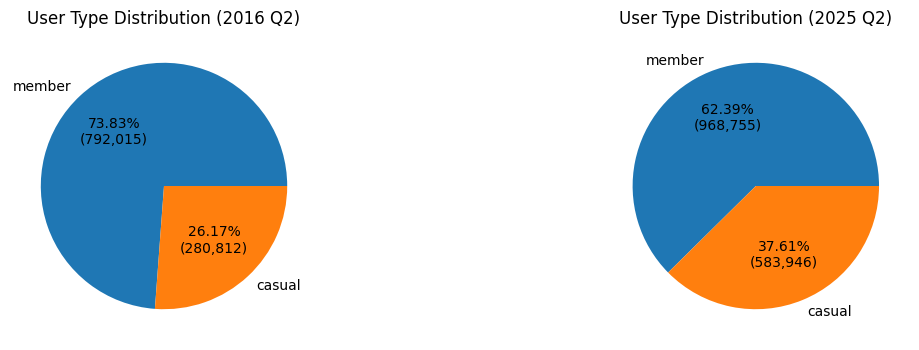

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,4))
count_df = df['user_type'].value_counts().rename(year)
total_sum = count_df.sum()
count_df.plot(kind='pie', color=["blue", "orange"], 
                  autopct=lambda pct: f"{pct:.2f}%\n({int(round(pct * total_sum / 100)):,.0f})", 
                  ylabel='', ax=axes[0],
                  title='User Type Distribution (' + col_name + ")")

count_df2 = df2['user_type'].value_counts().rename(year2)
total_sum2 = count_df2.sum()
count_df2.plot(kind='pie', color=["blue", "orange"], 
                  autopct=lambda pct: f"{pct:.2f}%\n({int(round(pct * total_sum2 / 100)):,.0f})", 
                  ylabel='', ax=axes[1],
                  title='User Type Distribution (' + col_name2 + ")")

count_df = pd.concat([count_df, count_df2], axis=1)
count_df.index.name = None
count_df = pd.concat([count_df, pd.DataFrame([{year:total_sum, year2:total_sum2}], index=['Total'])])
count_df["increase"] = (count_df[year2]-count_df[year])/count_df[year] 
display(HTML('<span style="font-size: 16px; font-weight: bold;"> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Counts by user type  </span>'))
display(HTML(count_df.style.format({year:'{:,.0f}', year2:'{:,.0f}', 'increase':'{:.2%}'}).to_html()))

plt.show()

## 3. Anaysis
The analysis is conducted in two parts:  
* In‑depth analysis of Q2 2016 
* Trend analysis from 2016 to 2025


### A. In‑Depth Analysis: Q2 2016

#### 1. Load Data and Check
The Q2 2016 dataset contains 1,072,827 records with no missing values. Annual members account for 74% of trips, indicating they use the service roughly three times more than casual riders.

In [12]:
# load data files of year 2016 and Quater 2.
year = 2016
qter = 'Q2'
df = read_data(file_df[(file_df['year'] == year) & (file_df['qter'] == qter)])
df.sample(5)

Divvy_Trips_2016_06.csv! Divvy_Trips_2016_05.csv! Divvy_Trips_2016_04.csv! 

,index,started,stoped,user_type,from_station_name,duration,dayofweek
835535,835535,2016-05-02 08:51:00,2016-05-02 08:56:00,member,Clark St & Grace St,300.0,1
515723,515723,2016-05-29 15:51:00,2016-05-29 16:01:00,casual,Clark St & Elm St,600.0,7
975941,975941,2016-04-16 16:44:00,2016-04-16 16:49:00,casual,Larrabee St & Webster Ave,300.0,6
162144,162144,2016-06-21 07:40:00,2016-06-21 07:54:00,member,State St & Kinzie St,840.0,2
262848,262848,2016-06-15 06:35:00,2016-06-15 06:42:00,member,Clinton St & Washington Blvd,420.0,3


In [13]:
print(f"Total Records: {len(df):,.0f}")
df.isnull().sum()

Total Records: 1,072,827


index                0
started              0
stoped               0
user_type            0
from_station_name    0
duration             0
dayofweek            0
dtype: int64

Out of a total of 1,072,827 records, there is no missing data in the dataset used for analysis.  
The pie chart below shows the proportion of annual members and casual riders in Q2 2016. Annual members account for 74% of all trips, indicating significantly higher usage compared to casual riders.

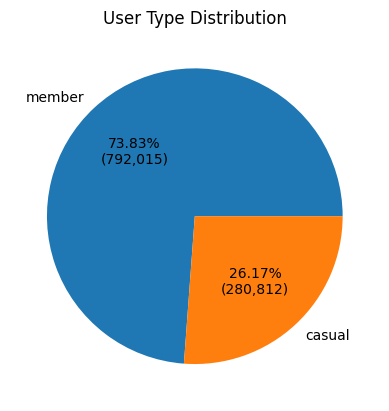

In [14]:
count_df = df['user_type'].value_counts().rename(year)
total_sum = count_df.sum()
count_df.plot(kind='pie', color=["blue", "orange"], 
                  autopct=lambda pct: f"{pct:.2f}%\n({int(round(pct * total_sum / 100)):,.0f})", 
                  ylabel='', title='User Type Distribution')
plt.show()

#### 2. Day‑of‑Week and Hourly Trends
* Annual members ride mostly on weekdays → commuting behavior
* Casual riders ride mostly on weekends → leisure behavior
  
Hourly analysis shows:
* Members peak at 6–9 AM and 4–6 PM
* Casual riders peak in the afternoon

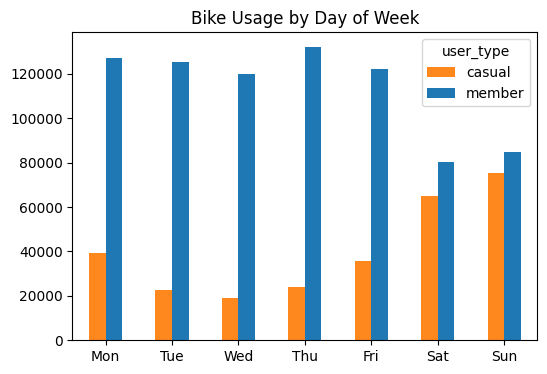

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
casual,"39,280","22,628","19,122","23,822","35,548","64,963","75,449"
member,"127,287","125,192","119,931","132,127","122,123","80,498","84,857"


In [15]:
count_df = df.value_counts(['dayofweek','user_type']).sort_index().unstack()
count_df.index=['Mon','Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
count_df.plot(kind='bar', figsize=(6, 4), rot=0, color=["#FF881E", "#1f77b4"], title='Bike Usage by Day of Week')
plt.show()

count_df = count_df.T
count_df.index.name = None
count_df.style.format(precision=0, thousands=",", decimal=".")

The bar chart above shows that annual members primarily ride on weekdays, reflecting commuting behavior, while casual riders show higher activity on weekends, suggesting leisure‑oriented usage.

This becomes even more apparent when looking at the bar chart below showing bike usage by time of day: Members exhibit clear morning and evening peaks aligned with commute hours (6–9 AM and 4–6 PM). Casual riders ride mostly in the afternoon, consistent with recreational use.

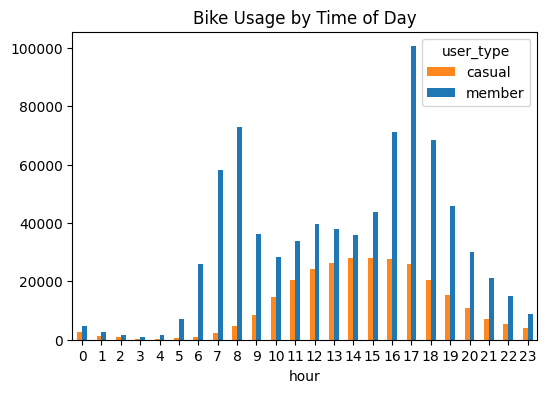

In [16]:
df['hour'] = df.started.dt.hour
count_df = df.value_counts(['hour','user_type']).sort_index().unstack()
count_df.plot(kind='bar', figsize=(6, 4), rot=0, color=["#FF881E", "#1f77b4"], title='Bike Usage by Time of Day')
plt.show()

#### 3. Start Station Analysis
Top stations reveal:
* Members start near office‑dense areas
* Casual riders start near tourist or lakeside locations

Casual riders show a highly concentrated pattern: nearly 30% of trips originate from the top 10 stations.

In [17]:
# Top 10 Starting Station

count_df = df.value_counts(['from_station_name','user_type']).unstack()
count_df.index.name = None
count_df['member_p'] = count_df.member / count_df.member.sum() * 100
count_df['casual_p'] = count_df.casual / count_df.casual.sum() * 100
count_df.columns.name= None
count_summary = pd.concat([count_df[['member', 'member_p']].nlargest(1000, 'member').reset_index(names='memeber_station'), 
                           count_df[['casual', 'casual_p']].nlargest(1000, 'casual').reset_index(names='casual_station')], axis=1)

tmp_df = count_summary.head(10)
tmp_df = pd.concat([tmp_df, pd.DataFrame({'memeber_station':['Total:'], 'member':[tmp_df.member.sum()], 'member_p':[tmp_df.member_p.sum()],
              'casual_station':['Total:'], 'casual':[tmp_df.casual.sum()], 'casual_p':[tmp_df.casual_p.sum()]})])
tmp_df

,memeber_station,member,member_p,casual_station,casual,casual_p
0,Clinton St & Washington Blvd,12644.0,1.596434,Streeter Dr & Grand Ave,20973.0,7.468698
1,Clinton St & Madison St,10550.0,1.332045,Lake Shore Dr & Monroe St,12221.0,4.352022
2,Canal St & Madison St,9837.0,1.242022,Lake Shore Dr & North Blvd,9609.0,3.421862
3,Canal St & Adams St,8723.0,1.101368,Theater on the Lake,8446.0,3.007706
4,Canal St & Jackson Blvd,8145.0,1.028390,Millennium Park,8335.0,2.968178
5,Kingsbury St & Kinzie St,7705.0,0.972835,Michigan Ave & Oak St,7717.0,2.748102
6,Franklin St & Monroe St,7704.0,0.972709,Shedd Aquarium,7020.0,2.499893
7,Theater on the Lake,7525.0,0.950108,Adler Planetarium,5059.0,1.801561
8,Lake Shore Dr & North Blvd,6534.0,0.824984,Dusable Harbor,4806.0,1.711465
9,Clinton St & Lake St,6394.0,0.807308,Burnham Harbor,4395.0,1.565104


As shown in the table listing the top 10 starting locations, annual members tend to start trips near office‑dense areas, while casual riders begin trips near tourist attractions and lakeside locations. 

Furthermore, the bar chart below reveals that __while members exhibit a relatively even distribution of usage, casual riders show a more concentrated pattern__, with nearly 30% of them starting their trips from the top 10 locations.

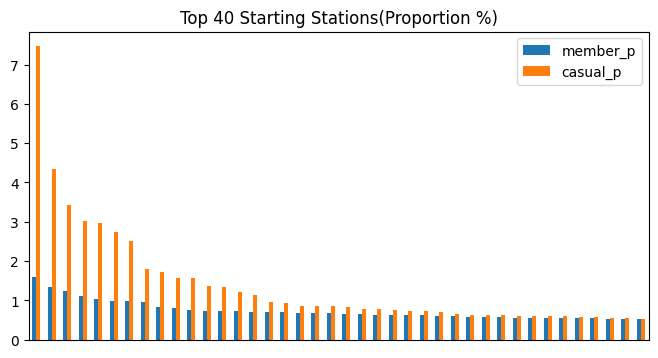

In [18]:
count_summary[['member_p', 'casual_p']][:40].plot(kind='bar', figsize=(8,4), title='Top 40 Starting Stations(Proportion %)')
plt.xticks([])
plt.show()

#### 4. Trip Duration Analysis
Members average 13 minutes
* Casual riders average 31 minutes
* Casual riders show much wider duration variability
* Long‑duration rides (1–3+ hours) are disproportionately taken by casual riders.

To reduce memory usage for long‑term analysis, durations are binned:
* ≤ 3 hours: 5‑minute bins
* \> 3 hours: 30‑minute bins

Records with durations < 0 or > 24 hours are removed.

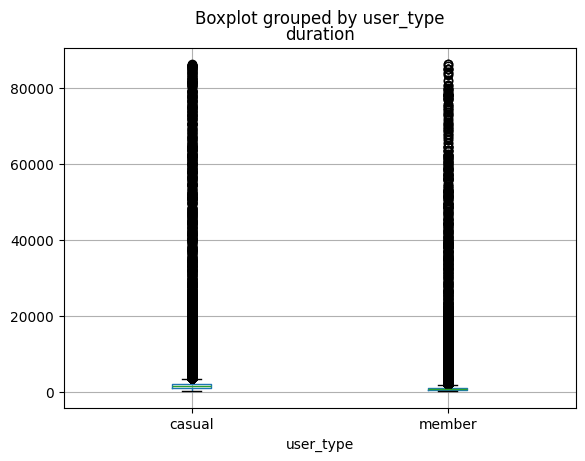

In [19]:
df.boxplot(column='duration', by='user_type')
plt.show()

A box plot was used to examine the data distribution, which reveals that the data is overall skewed toward one side (the green section at the bottom).  
This is clearly reflected in the results of the kdeplot below; it is necessary to analyze the 'duration' by breaking it down into finer intervals.

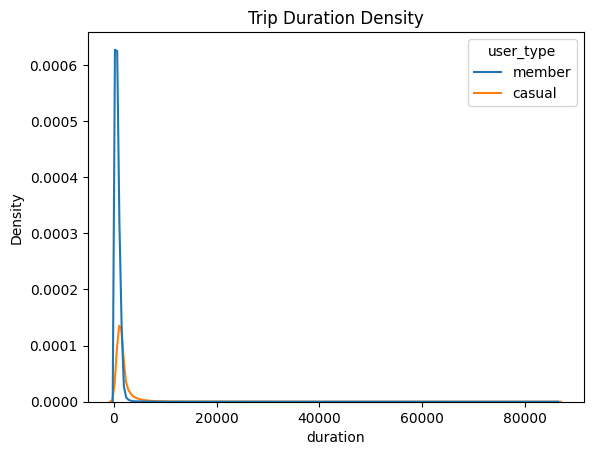

In [20]:
ax = sns.kdeplot(data=df, x="duration", hue="user_type")
ax.set_title("Trip Duration Density")
plt.show()

In [21]:
stat_df = pd.DataFrame(df[df['user_type'] == 'member'].describe()['duration'])
stat_df.rename(columns={"duration":"member"}, inplace=True)
stat_df['casual'] = pd.DataFrame(df[df['user_type'] == 'casual'].describe()['duration'])

display(HTML(stat_df.style.format(precision=2, thousands=",", decimal=".").to_html()))

df.groupby('user_type').agg({'duration': ['skew', pd.Series.kurt]})

,member,casual
count,"792,015.00","280,812.00"
mean,758.83,"1,881.45"
min,60.00,60.00
25%,360.00,900.00
50%,600.00,"1,380.00"
75%,960.00,"1,920.00"
max,"86,220.00","86,280.00"
std,"1,374.44","3,216.76"


duration             
                skew         kurt
user_type                        
casual     14.770852   295.816808
member     34.616508  1557.266329

The average duration is 758 seconds (13 minutes) for members and 1,881 seconds (31 minutes) for casual riders, indicating that casual riders use the service for 2.5 times longer.  
With standard deviations of 1,374 and 3,216, respectively, the data shows that __casual riders exhibit a more widely dispersed distribution.__

As visualized in the chart below; the average usage time for casual riders is skewed toward the 75th percentile of the distribution, and there are many users who ride for significantly longer periods, and the skewness and kurtosis values above also show the same result.

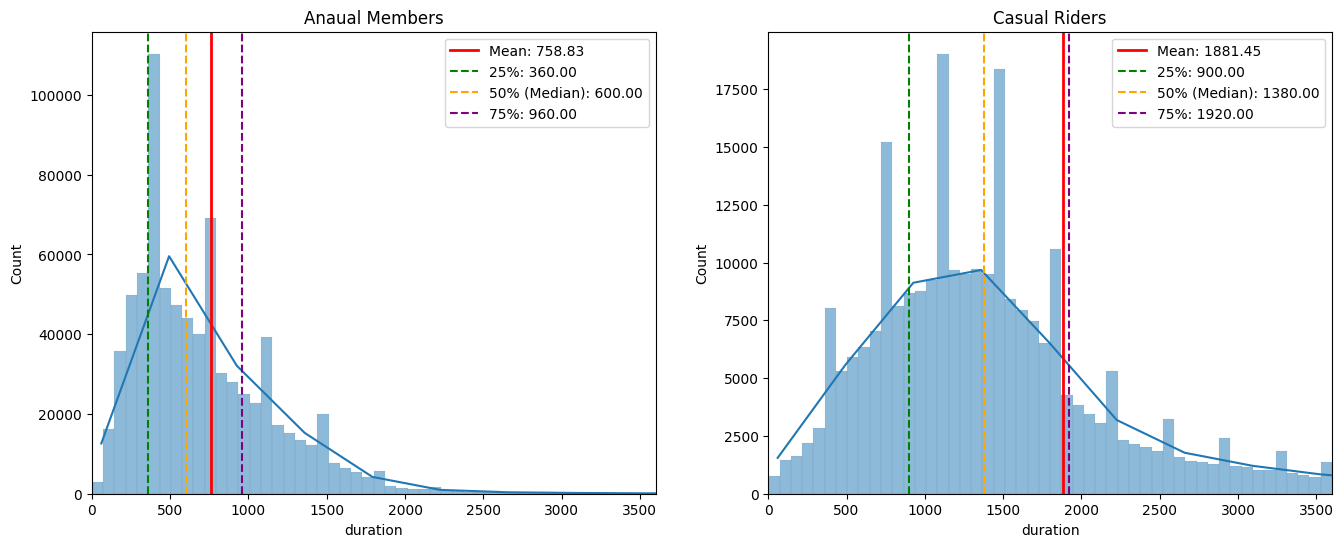

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,6))
max_size = 3600

sns.histplot(data=df[df['user_type']=='member'], x="duration", kde=True, bins=50, binrange=(0, max_size), ax = axes[0])
mean_val = stat_df.loc["mean", 'member']
q25 = stat_df.loc["25%", 'member']
q50 = stat_df.loc["50%", 'member']
q75 = stat_df.loc["75%", 'member']

axes[0].set(title="Anaual Members")
axes[0].set_xlim(0, max_size)
axes[0].axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')
axes[0].axvline(q25, color='green', linestyle='--', linewidth=1.5, label=f'25%: {q25:.2f}')
axes[0].axvline(q50, color='orange', linestyle='--', linewidth=1.5, label=f'50% (Median): {q50:.2f}')
axes[0].axvline(q75, color='purple', linestyle='--', linewidth=1.5, label=f'75%: {q75:.2f}')
axes[0].legend()

sns.histplot(data=df[df['user_type']=='casual'], x="duration", kde=True, bins=50, binrange=(0, max_size), ax = axes[1])
mean_val = stat_df.loc["mean", 'casual']
q25 = stat_df.loc["25%", 'casual']
q50 = stat_df.loc["50%", 'casual']
q75 = stat_df.loc["75%", 'casual']

axes[1].set(title="Casual Riders")
axes[1].set_xlim(0, max_size)
axes[1].axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')
axes[1].axvline(q25, color='green', linestyle='--', linewidth=1.5, label=f'25%: {q25:.2f}')
axes[1].axvline(q50, color='orange', linestyle='--', linewidth=1.5, label=f'50% (Median): {q50:.2f}')
axes[1].axvline(q75, color='purple', linestyle='--', linewidth=1.5, label=f'75%: {q75:.2f}')
axes[1].legend()

plt.show()

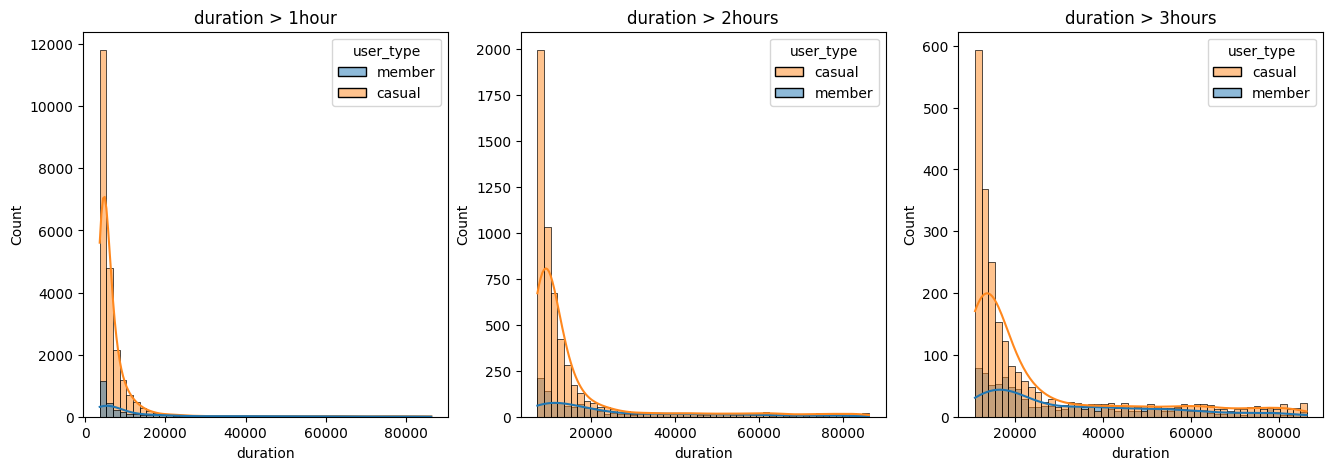

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

sns.histplot(data=df[(df['duration']>3600)], x="duration", hue="user_type", kde=True, bins=50, ax = axes[0], palette={"member":"#1f77b4", "casual":"#FF881E"})
axes[0].set(title="duration > 1hour")
sns.histplot(data=df[(df['duration']>7200)], x="duration", hue="user_type", kde=True, bins=50, ax = axes[1], palette={"member":"#1f77b4", "casual":"#FF881E"})
axes[1].set(title="duration > 2hours")
sns.histplot(data=df[(df['duration']>10800)], x="duration", hue="user_type", kde=True, bins=50, ax = axes[2], palette={"member":"#1f77b4", "casual":"#FF881E"})
axes[2].set(title="duration > 3hours")
plt.show()

The charts above display user counts for durations of over 1 hour, over 2 hours, and over 3 hours; while usage remains high across these categories, casual riders generally account for a larger share.  
However, a direct comparison based on raw counts is misleading because the total number of members significantly exceeds that of casual riders (792,015 vs. 280,812).  
Therefore, comparing the data by proportion—as shown below—allows for a better analysis of the distribution at the upper end of the duration range; this reveals that casual riders are more likely to engage in long-duration rides, particularly in the "duration > 3 hours" category.
As seen below, __the result of duration over 3 hours(108,000seconds) more clearly illustrate the differences between annual members and casual riders.__

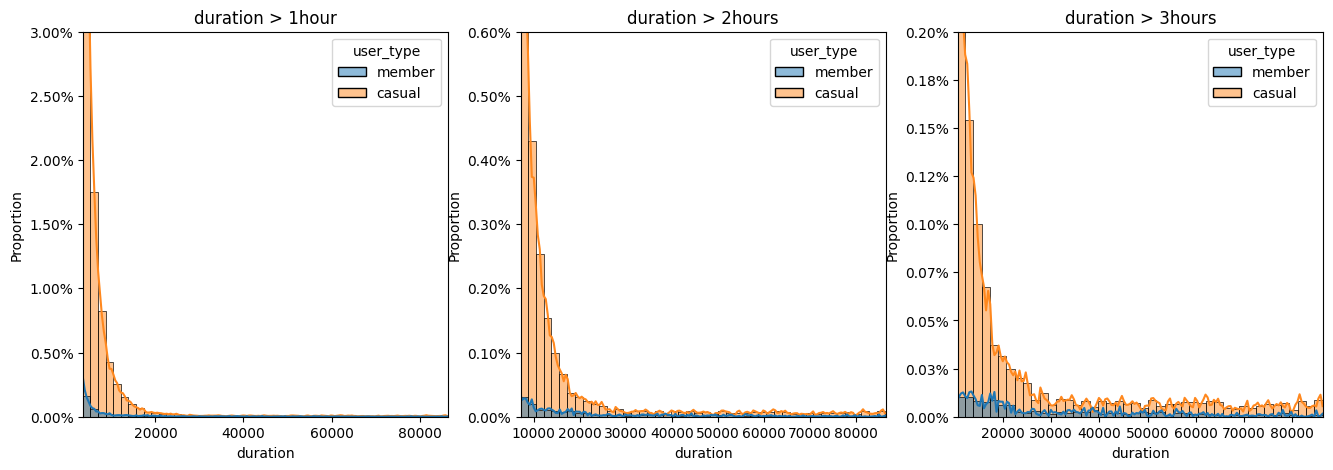

In [24]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

sns.histplot(data=df, x="duration", hue="user_type", kde=True, bins=50, ax = axes[0], palette={"member":"#1f77b4", "casual":"#FF881E"}, stat='proportion', common_norm=False)
axes[0].set_xlim(3600, 86400)
axes[0].set_ylim(0, 0.03)
axes[0].set(title="duration > 1hour")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val * 100:.2f}%'))
sns.histplot(data=df, x="duration", hue="user_type", kde=True, bins=50, ax = axes[1], palette={"member":"#1f77b4", "casual":"#FF881E"}, stat='proportion', common_norm=False)
axes[1].set_xlim(7200, 86400)
axes[1].set_ylim(0, 0.006)
axes[1].set(title="duration > 2hours")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val * 100:.2f}%'))
sns.histplot(data=df, x="duration", hue="user_type", kde=True, bins=50, ax = axes[2], palette={"member":"#1f77b4", "casual":"#FF881E"}, stat='proportion', common_norm=False)
axes[2].set_xlim(10800, 86400)
axes[2].set_ylim(0, 0.002)
axes[2].set(title="duration > 3hours")
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val * 100:.2f}%'))
plt.show()

The method described above has a drawback: it requires retaining all data as the total number of rows increases. Since the upcoming comparative analysis covering the entire period from 2016 to 2025 could place __a heavy load on the system, it is necessary to consider a more lightweight approach with the same result.__  
  
As shown in the previous analysis, the data will be divided into two segments based on a 3-hour(10,800-second) threshold: bins will be created at 5-minute(300-second) intervals for the period up to 3 hours, and at 30-minute(1,800-second) intervals for the period beyond 3 hours, after which the counts for each bin will be extracted for comparative analysis.  
  
Additionally, since data points exceeding 24 hours (86,400 seconds) or falling below 0 seconds do not contribute to an accurate analysis, the corresponding rows will be removed.

In [25]:
# drop if one day order...
df.drop(df[df['duration'] > 86400].index, inplace=True)
# drop duration is below zero...
df.drop(df[df['duration'] <= 0].index, inplace=True)

# crate bins 
bin_edges = np.concatenate((np.arange(0, 10800, 300), np.arange(10800, 86400, 1800)), axis=0)

# Add bins to dataframe
df['bins'] = pd.cut(df['duration'], bins=bin_edges, labels=bin_edges[1:], right=True)

# count by bins and user type
count_df = pd.crosstab(df['bins'], df['user_type'])

count_df = count_df.reindex(columns=['member', 'casual'])
count_df.reset_index(inplace=True)

# add proportion column for each user type
count_df['member_p'] = count_df['member'] / count_df['member'].sum() * 100
count_df['casual_p'] = count_df['casual'] / count_df['casual'].sum() * 100
count_df.index.name = None
count_df.head(5).style.format(precision=2, thousands=",", decimal=".")

user_type,bins,member,casual,member_p,casual_p
0,300,"160,392","8,929",20.25,3.18
1,600,"253,188","25,623",31.97,9.13
2,900,"167,605","39,062",21.16,13.91
3,"1,200","104,361","46,727",13.18,16.64
4,"1,500","61,090","47,140",7.71,16.79


As shown in the table above, for anual members, 75% fall within three bins and 95% within five bins, whereas for "casual" users, the corresponding figures are 26% and 60%, respectively.  
And the results shown in the plots below are resembled result to those presented in the previous histogram.

<Axes: title={'center': 'Proportion(%) of duration > 3 hours'}, xlabel='bins'>

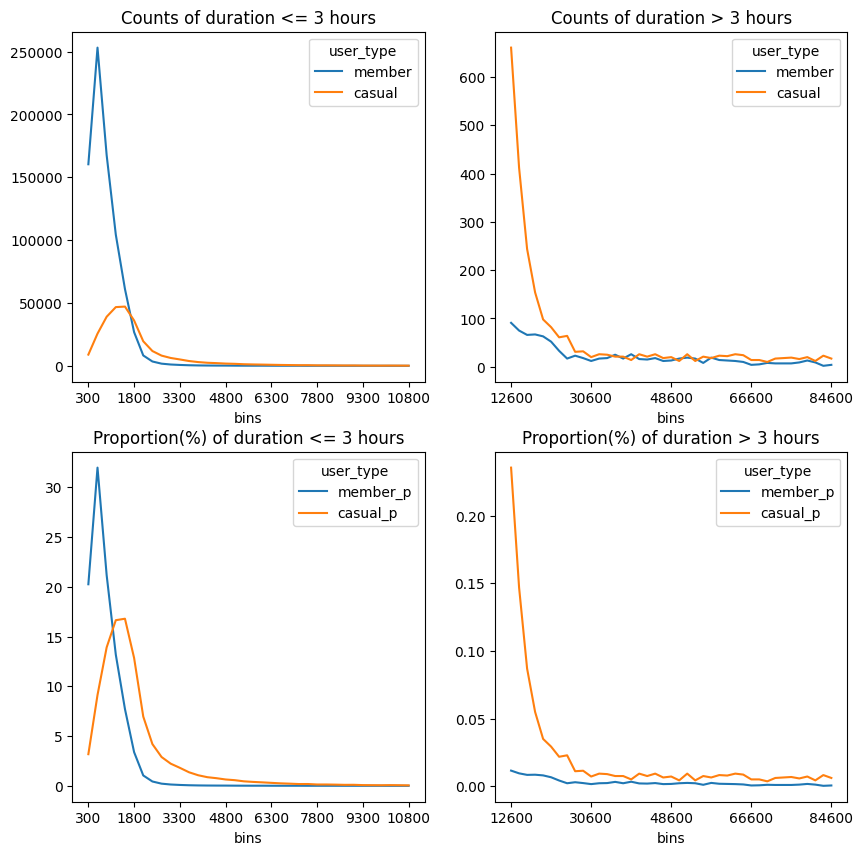

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

count_df[count_df['bins'] <= 10800].plot(kind='line', x='bins', y=['member', 'casual'], ax=axes[0,0], title="Counts of duration <= 3 hours")
count_df[count_df['bins'] > 10800].plot(kind='line', x='bins', y=['member', 'casual'], ax=axes[0,1], title="Counts of duration > 3 hours")

count_df[count_df['bins'] <= 10800].plot(kind='line', x='bins', y=['member_p', 'casual_p'], ax=axes[1,0], title="Proportion(%) of duration <= 3 hours")
count_df[count_df['bins'] > 10800].plot(kind='line', x='bins', y=['member_p', 'casual_p'], ax=axes[1,1], title="Proportion(%) of duration > 3 hours")

### B. Trend Analysis: 2016–2025

In this process, we will move beyond the previous in-depth analysis to conduct a trend analysis using integrated data spanning from 2016 to 2025: Examine how the results of the individual analyses have evolved over this ten-year period and use those findings to perform a comprehensive analysis.

#### 1. Load Data and Check
Only from_station_name contains null values, increasing to 23% by 2025. However, missing values are evenly distributed across stations, so station‑based analysis remains reliable.  
  
Casual ridership increased dramatically:
* Members: +25% (2019 → 2025)
* Casual riders: +129% (2019 → 2025)

A sharp drop in member usage in 2020 aligns with pandemic‑related remote work.  
  
Casual rider share increased across all quarters starting in 2020.

In [27]:
# Bins for counting by duration bucket for count_duration function below
bin_edges = np.concatenate((np.arange(0, 10800, 300), np.arange(10800, 86400, 1800)), axis=0)

def count_duration(df):
    """
    A function that counts durations by bin and converts the counts into proportions..
    Args:
        df: dataframe to do the work
    Returns:
        dataframe: DataFrame result of the counted durations 
    Example:
        >>> count_df = count_ducation(df)
    """
    # drop duration is below zero...
    df.drop(df[df['duration'] <= 0].index, inplace=True)
    # drop if one day order...
    df.drop(df[df['duration'] > 86400].index, inplace=True)
    
    df['bins'] = pd.cut(df['duration'], bins=bin_edges, labels=bin_edges[1:], right=True)
    count_df = pd.crosstab(df['bins'], df['user_type'])
    count_df.reset_index(inplace=True)
    count_df['member_p'] = count_df['member'] / count_df['member'].sum() * 100
    count_df['casual_p'] = count_df['casual'] / count_df['casual'].sum() * 100
    return count_df

In [28]:
idx = 0

years = []

mean_m = [[],[],[],[]]
mean_c = [[],[],[],[]]

zero_m = [[],[],[],[]]
zero_c = [[],[],[],[]]

oneday_m = [[],[],[],[]]
oneday_c = [[],[],[],[]]

duration_dfs = [[],[],[],[]]
weekcount_dfs = [[],[],[],[]]
count_dfs = [[],[],[],[]]
hour_dfs = [[],[],[],[]]
weekdayhour_dfs = [[],[],[],[]]
from_dfs = [[],[],[],[]]
station_ranking_df = [[],[],[],[]]

null_df = pd.DataFrame()

print("started!")

for x in range(2016, 2026):
    # processing yearly 
    years.append(str(x))
    i = 0
    for q in ['Q1', 'Q2', 'Q3', 'Q4']:
        # processing quaterly 
        df = read_data(file_df[(file_df['year'] == x) & (file_df['qter'] == q)])

        # processing null info
        null_info = df.isnull().sum().to_frame(str(x) + " " + q)
        null_info.loc['index'] = len(df)
        null_info.rename(index={'index': 'Total Records'}, inplace=True)
        null_df = pd.concat([null_df, null_info], axis=1)

        # store counts of duration that exeeds one day and below zero by user types
        zero_m[i].append(sum((df['duration'] <= 0) & (df['user_type'] == 'member')))
        zero_c[i].append(sum((df['duration'] <= 0) & (df['user_type'] == 'casual')))
        oneday_m[i].append(sum((df['duration'] > 86400) & (df['user_type'] == 'member')))
        oneday_c[i].append(sum((df['duration'] > 86400) & (df['user_type'] == 'casual')))

        # processing day of week
        count_dfs[i].append(df['user_type'].value_counts())
        weekcount_dfs[i].append(df.value_counts(['dayofweek','user_type']).sort_index().unstack())

        # processing duration by calling function count_duration 
        duration_dfs[i].append(count_duration(df))

        # store mean value of user type member
        agg_df = df.groupby('user_type').agg({'duration': 'mean'})
        mean_m[i].append(agg_df.loc['member','duration'])
        mean_c[i].append(agg_df.loc['casual','duration'])

        # processing start hour by user types
        df['hour'] = df.started.dt.hour
        hour_dfs[i].append(df.value_counts(['hour','user_type']).sort_index().unstack())
        # processing start hour by user types with weekday only
        weekdayhour_dfs[i].append(df[df['dayofweek'].isin([1,2,3,4,5])].value_counts(['hour','user_type']).sort_index().unstack())

        # processing with ranking start station name by user types
        count_df = df.value_counts(['from_station_name','user_type']).unstack()
        count_df.index.name = None
        count_df['member_p'] = count_df.member / count_df.member.sum() * 100
        count_df['casual_p'] = count_df.casual / count_df.casual.sum() * 100
        count_df.columns.name= None
        station_ranking_df[i].append(pd.concat([count_df[['member', 'member_p']].nlargest(1000, 'member').reset_index(names='memeber_station'), 
                                   count_df[['casual', 'casual_p']].nlargest(1000, 'casual').reset_index(names='casual_station')], axis=1))

        i += 1

    idx += 1
    
print("\033[31mcompleted!!\033[0m")

started!
Divvy_Trips_2016_Q1.csv! Divvy_Trips_2016_06.csv! Divvy_Trips_2016_05.csv! Divvy_Trips_2016_04.csv! Divvy_Trips_2016_Q3.csv! Divvy_Trips_2016_Q4.csv! Divvy_Trips_2017_Q1.csv! Divvy_Trips_2017_Q2.csv! Divvy_Trips_2017_Q3.csv! Divvy_Trips_2017_Q4.csv! Divvy_Trips_2018_Q1.csv! Divvy_Trips_2018_Q2.csv! Divvy_Trips_2018_Q3.csv! Divvy_Trips_2018_Q4.csv! Divvy_Trips_2019_Q1.csv! Divvy_Trips_2019_Q2.csv! Divvy_Trips_2019_Q3.csv! Divvy_Trips_2019_Q4.csv! Divvy_Trips_2020_Q1.csv! 202004-divvy-tripdata.csv! 202006-divvy-tripdata.csv! 202005-divvy-tripdata.csv! 202009-divvy-tripdata.csv! 202008-divvy-tripdata.csv! 202007-divvy-tripdata.csv! 202012-divvy-tripdata.csv! 202011-divvy-tripdata.csv! 202010-divvy-tripdata.csv! 202101-divvy-tripdata.csv! 202102-divvy-tripdata.csv! 202103-divvy-tripdata.csv! 202104-divvy-tripdata.csv! 202106-divvy-tripdata.csv! 202105-divvy-tripdata.csv! 202107-divvy-tripdata.csv! 202108-divvy-tripdata.csv! 202109-divvy-tripdata.csv! 202111-divvy-tripdata.csv! 202

In [29]:
# missing data check
null_df.style.format(precision=0, thousands=",", decimal=".")

,2016 Q1,2016 Q2,2016 Q3,2016 Q4,2017 Q1,2017 Q2,2017 Q3,2017 Q4,2018 Q1,2018 Q2,2018 Q3,2018 Q4,2019 Q1,2019 Q2,2019 Q3,2019 Q4,2020 Q1,2020 Q2,2020 Q3,2020 Q4,2021 Q1,2021 Q2,2021 Q3,2021 Q4,2022 Q1,2022 Q2,2022 Q3,2022 Q4,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3,2025 Q4
Total Records,"396,913","1,072,827","1,441,785","683,818","431,687","1,119,814","1,608,267","669,239","387,145","1,059,681","1,513,570","642,686","365,069","1,108,163","1,640,718","704,054","426,887","628,055","1,706,799","779,942","374,952","1,598,458","2,382,909","1,238,744","503,421","1,775,311","2,310,759","1,078,226","639,424","1,751,035","2,205,714","1,123,704","669,724","1,735,239","2,325,877","1,129,728","726,511","1,552,701","2,268,368","1,143,201"
started,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
stoped,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
user_type,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
from_station_name,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,888,"34,375","75,617","32,362","172,755","286,534","247,519","89,439","268,611","352,658","182,034","93,016","287,947","363,163","185,076","93,040","339,277","474,399","197,937","136,901","337,843","530,749","265,407"
duration,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
dayofweek,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


An examination of null check results for data from 2016 to 2025 reveals no columns containing null values, with the exception of the "from station name" column.  
Null values ​​appear in the "from station name" field starting in Q1 2020; The table below presents this as a percentage; the figure has steadily increased since the first quarter of 2020, showing a missing value rate exceeding 20% ​​in 2025.  
  
Accordingly, we examined the station latitudes using the Q3 2025 data—which contained the highest number of missing values—and the results are shown in the chart titled "Histogram where from station name is missing." The distribution reveals no significant difference compared to the chart named "Histogram where from station name exists" shown on the right.  
  
This indicates that although the missing data rate reaches 23%, the missing values occured evenly across all stations rather than being concentrated in specific ones; therefore, __analysis results based on the "from station name" can be considered highly reliable.__

In [30]:
# percentage of missing data
tmp_df = null_df.iloc[1:,:]/null_df.iloc[0,:] 
tmp_df.style.map(color_positive).format(format_positive)

,2016 Q1,2016 Q2,2016 Q3,2016 Q4,2017 Q1,2017 Q2,2017 Q3,2017 Q4,2018 Q1,2018 Q2,2018 Q3,2018 Q4,2019 Q1,2019 Q2,2019 Q3,2019 Q4,2020 Q1,2020 Q2,2020 Q3,2020 Q4,2021 Q1,2021 Q2,2021 Q3,2021 Q4,2022 Q1,2022 Q2,2022 Q3,2022 Q4,2023 Q1,2023 Q2,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3,2025 Q4
started,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
stoped,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
user_type,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
from_station_name,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0%,0.1%,2.0%,9.7%,8.6%,10.8%,12.0%,20.0%,17.8%,15.1%,15.3%,16.9%,14.5%,16.4%,16.5%,16.5%,13.9%,19.6%,20.4%,17.5%,18.8%,21.8%,23.4%,23.2%
duration,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
dayofweek,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


202508-divvy-tripdata.csv! 202507-divvy-tripdata.csv! 202509-divvy-tripdata.csv! 

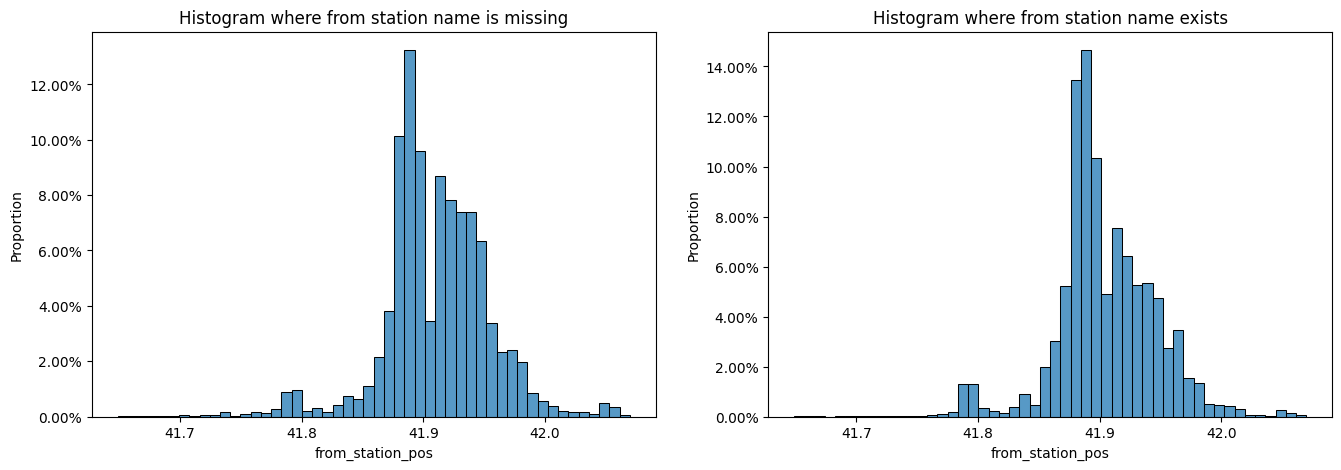

In [31]:
import matplotlib.ticker as ticker

# read year 2025 quater 3 with from_station_pos column that contains from station lattitude data
df = read_data(file_df[(file_df['year'] == 2025) & (file_df['qter'] == 'Q3')], True)

df_null = df[df['from_station_name'].isnull()]
df_notnull = df.dropna(subset=['from_station_name'])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

sns.histplot(data=df_null, x='from_station_pos', bins=50, ax = axes[0], stat='proportion')
axes[0].set(title="Histogram where from station name is missing")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val * 100:.2f}%'))

sns.histplot(data=df_notnull, x='from_station_pos', bins=50, ax = axes[1], stat='proportion')
axes[1].set(title="Histogram where from station name exists")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val * 100:.2f}%'))
plt.show()

In [32]:
from matplotlib.gridspec import SubplotSpec
import matplotlib.ticker as ticker

def create_subtitle(fig: plt.Figure, grid: SubplotSpec, title: str):
    """
    This function displays a title for subplot.
    Args:
        fig : The subset figure object
        grid : The location of the grid cells
        title : Title string
    Return : None
    Example : create_subtitle(fig, grid[0, ::], "Year : " + str(x))
    """
    row = fig.add_subplot(grid)
    # the '\n' is important
    row.set_title(f'{title}\n') #, fontweight='semibold')
    # hide subplot
    row.set_frame_on(False)
    row.axis('off')

def make_autopct(values):
    """
    This function show percent and original value together.
    Args:
        values : 
    Return : String to be displayed
    Example : make_autopct(count_df)
    """
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100000.0))
        return f'{pct:.1f}%\n({val:d}k)'
    return my_autopct

In [33]:
def draw_subplots(fun, maintitle='', size_w = 16, size_h = 4):
    """
    A function that draw n x 4  subplots by year(row) and quater(columns)
    Args:
        fun: function that draw plot for the year and quater
        size_w : width of the whole plot fig
        size_h : height of each row
    Returns:
        None 
    Example:
        >>> draw_subplots(lambda c, r, axes : weekcount_dfs[c][r].plot(kind='bar', color=["#FF881E", "#1f77b4"], rot=0, ax=axes[r, c]))
    """
    rows = len(years)
    cols = 4

    # create subplots
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(size_w, size_h*rows))
    fig.subplots_adjust(
        left=0.1, right=0.9, bottom=0.1, top=0.955, wspace=0.2, hspace=0.3
    )
    grid = plt.GridSpec(rows, cols)
    r = 0
    
    # set title for first row
    axes[0,0].set_title("Q1")
    axes[0,1].set_title("Q2")
    axes[0,2].set_title("Q3")
    axes[0,3].set_title("Q4")
    
    if maintitle != '':
        fig.suptitle(maintitle, fontsize=16, fontweight='bold')
    
    for x in years:
        # set sub title for each row(year)
        create_subtitle(fig, grid[r, ::], "Year : " + str(x))
        c = 0
        for q in ['Q1', 'Q2', 'Q3', 'Q4']:
            fun(r, c, axes)
            c += 1
        r += 1
        
    plt.show()

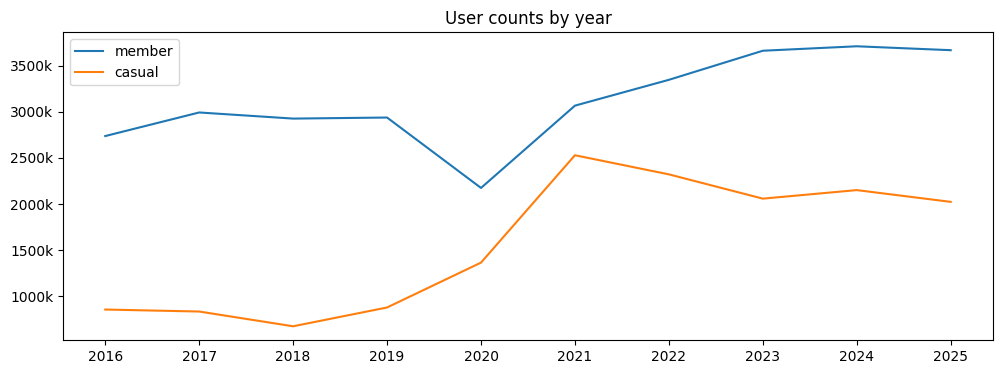

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
member,"2,736,869","2,992,135","2,925,926","2,937,367","2,175,108","3,066,058","3,345,685","3,660,698","3,708,910","3,666,535"
casual,"858,474","836,872","677,156","880,637","1,366,575","2,529,005","2,322,032","2,059,179","2,151,658","2,024,246"
Diff,"1,878,395","2,155,263","2,248,770","2,056,730","808,533","537,053","1,023,653","1,601,519","1,557,252","1,642,289"
Total,"3,595,343","3,829,007","3,603,082","3,818,004","3,541,683","5,595,063","5,667,717","5,719,877","5,860,568","5,690,781"


In [34]:
# User count by year
count_sum_m = []
count_sum_c = []
r = 0
for x in years:
    sum_m = 0
    sum_c = 0
    c = 0
    for q in ['Q1', 'Q2', 'Q3', 'Q4']:
        count_df = count_dfs[c][r]
        sum_m += int(count_df['member'])
        sum_c += int(count_df['casual'])
        c += 1
    count_sum_m.append(sum_m)
    count_sum_c.append(sum_c)
    r += 1

sum_df = pd.DataFrame({'year':years, 'member':count_sum_m, 'casual':count_sum_c})
ax = sum_df.plot(figsize=(12,4), title='User counts by year')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}k'))
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years) #, rotation=90)
plt.show()

sum_df.set_index('year', inplace=True)
sum_df['Diff'] = sum_df['member'] - sum_df['casual']
sum_df['Total'] = sum_df['member'] + sum_df['casual']
sum_df.T.style.format(precision=2, thousands=",", decimal=".")

As shown in the graph above, there is a significant difference in bike trip patterns starting from 2020. While the number of both members and casual riders increased, the growth among casual riders was far more pronounced.   
Comparing 2019 and 2025, the number of members rose by 25%—from 2.9 million to 3.7 million—whereas the number of casual riders surged by 129%, increasing from 0.9 million to 1.6 million.  
Notably, there was a sharp decline in bike usage by members in 2020—dropping from 2.9 million to 2.1 million—which appears to be the result of the increase in remote work caused by the pandemic.  
  
A more detailed look at the quarterly breakdown reveals significant shifts in the proportion of casual users: prior to 2020, the share rose from around 10% to over 20% in Q1; Q2 and Q3 saw increases from the 20–30% range to well over 40%; and Q4 also experienced a substantial rise from the 15% range to the 30% range.  
These changes became particularly pronounced starting in Q2 of 2020—coinciding with the pandemic—suggesting a massive influx of casual riders driven by social distancing measures.  
  
__Given these changes, a policy aimed at converting newly acquired casual riders into annual members is considered highly worthwhile.__

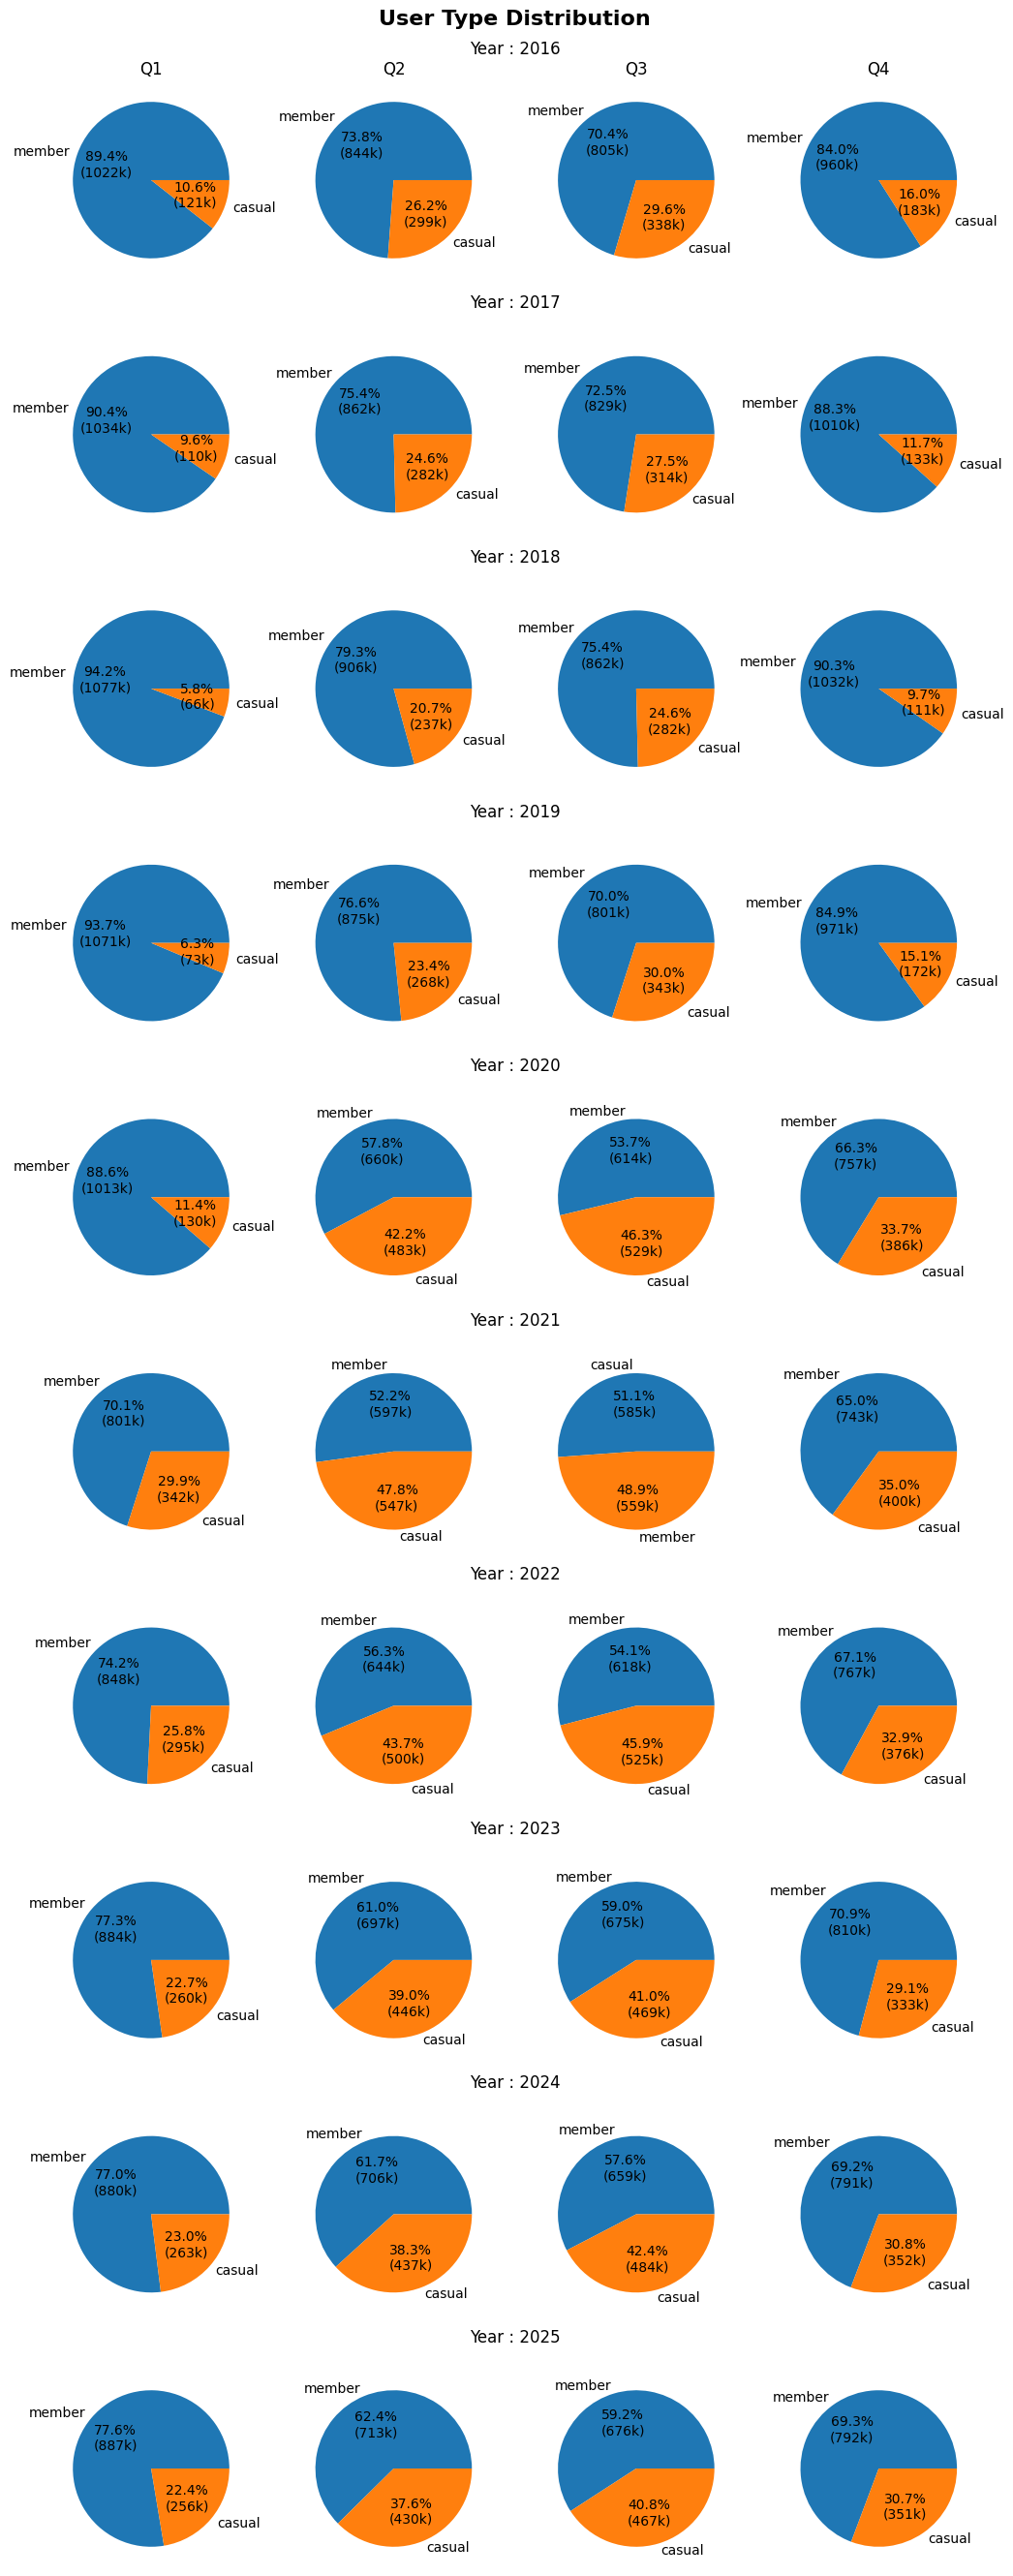

In [35]:
draw_subplots(lambda r, c, axes : count_dfs[c][r].plot(kind='pie', ax=axes[r, c], autopct=make_autopct(count_df), label=""), "User Type Distribution", 12, 3)

#### 2. Day‑of‑Week and Hourly Trends
Before 2020:
* Members → weekday commuting
* Casual → weekend leisure

After 2020:
* Casual weekday usage increased
* Casual time‑of‑day patterns became more complex
* Weekday‑only analysis shows a clear rise in casual commuting around 8 AM starting in late 2021

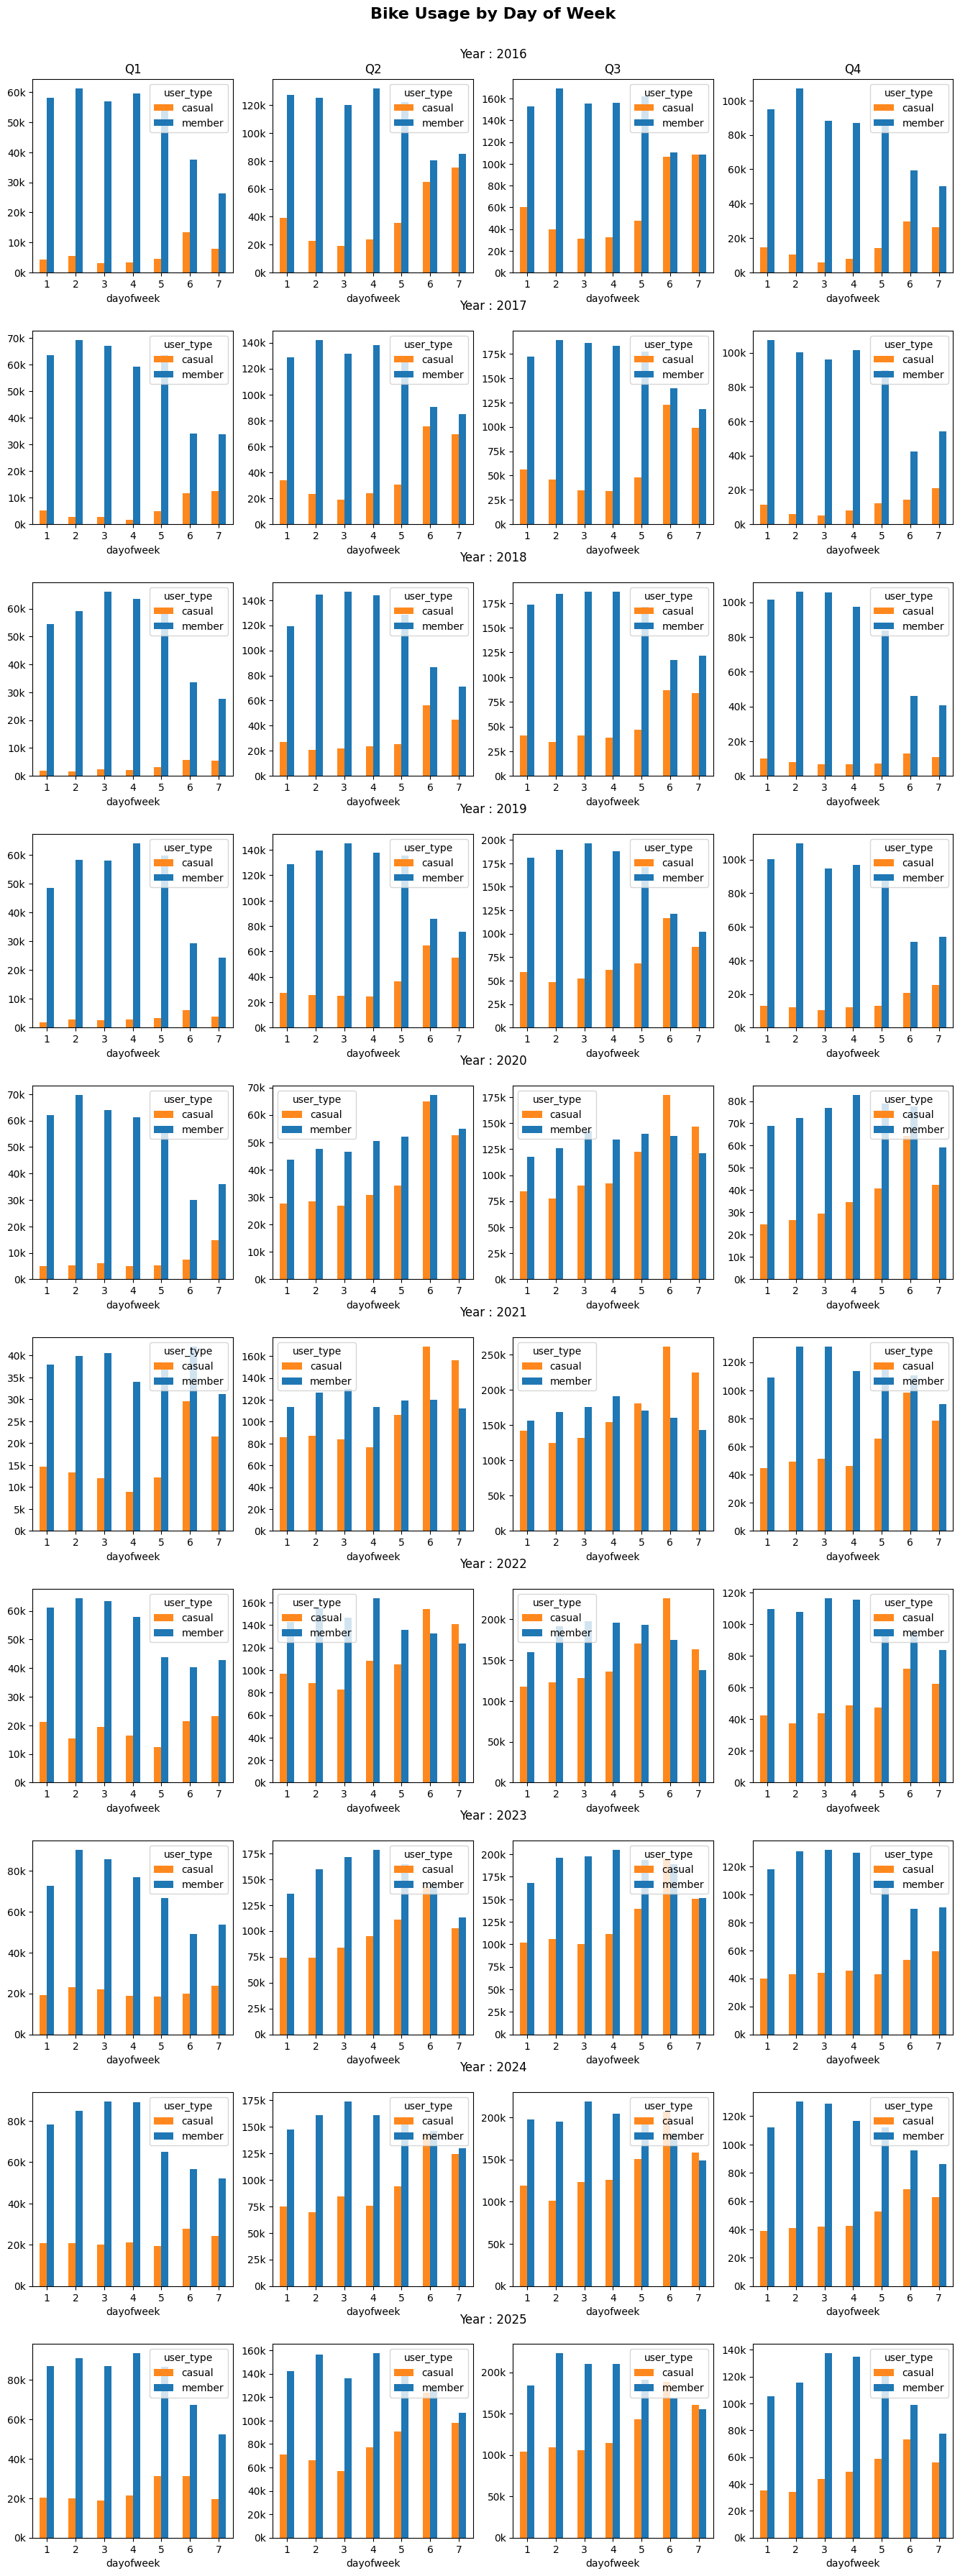

In [36]:
def draw_plot(r, c, axes):
    count_df = weekcount_dfs[c][r]
    count_df.plot(kind='bar', color=["#FF881E", "#1f77b4"], rot=0, ax=axes[r, c])
    axes[r,c].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}k'))

draw_subplots(draw_plot, "Bike Usage by Day of Week")

The bar chart above illustrates bike usage by day of week; prior to 2019, members primarily used the service on weekdays, whereas casual riders mostly used it on weekends—suggesting that members used the bikes for commuting, while casual riders used them for leisure or sightseeing.  
However, data from 2020 onwards shows significant usage by casual riders on weekdays as well, indicating a likely increase in the use of bikes for commuting or a shift toward routine, rather than one-off, usage.  
  
This pattern is more clearly illustrated in the time-based usage data below: members primarily use the service during commuting hours, from 7 AM to 9 AM and 4 PM to 6 PM, while casual riders show high usage rates during daytime hours. However, since 2020, casual users have exhibited significant changes; rather than simply showing a steady distribution during the day, their usage patterns have become complex and varied across different time slots.  

To examine these changes in greater detail, the same analysis was conducted using a dataset excluding weekends; the results are presented in the chart titled "Bike usage by time of day (weekdays only)." As shown in the chart, a significant increase in bike usage by casual riders around the 8:00 AM hour is evident starting in the third quarter of 2021—a period when the pandemic was gradually subsiding—indicating that a substantial number of casual riders use bicycles for commuting.  
  
__Based on the analysis by day of the week and time of day, we can actively consider ways to convert casual riders who use bicycles for commuting into annual members.__

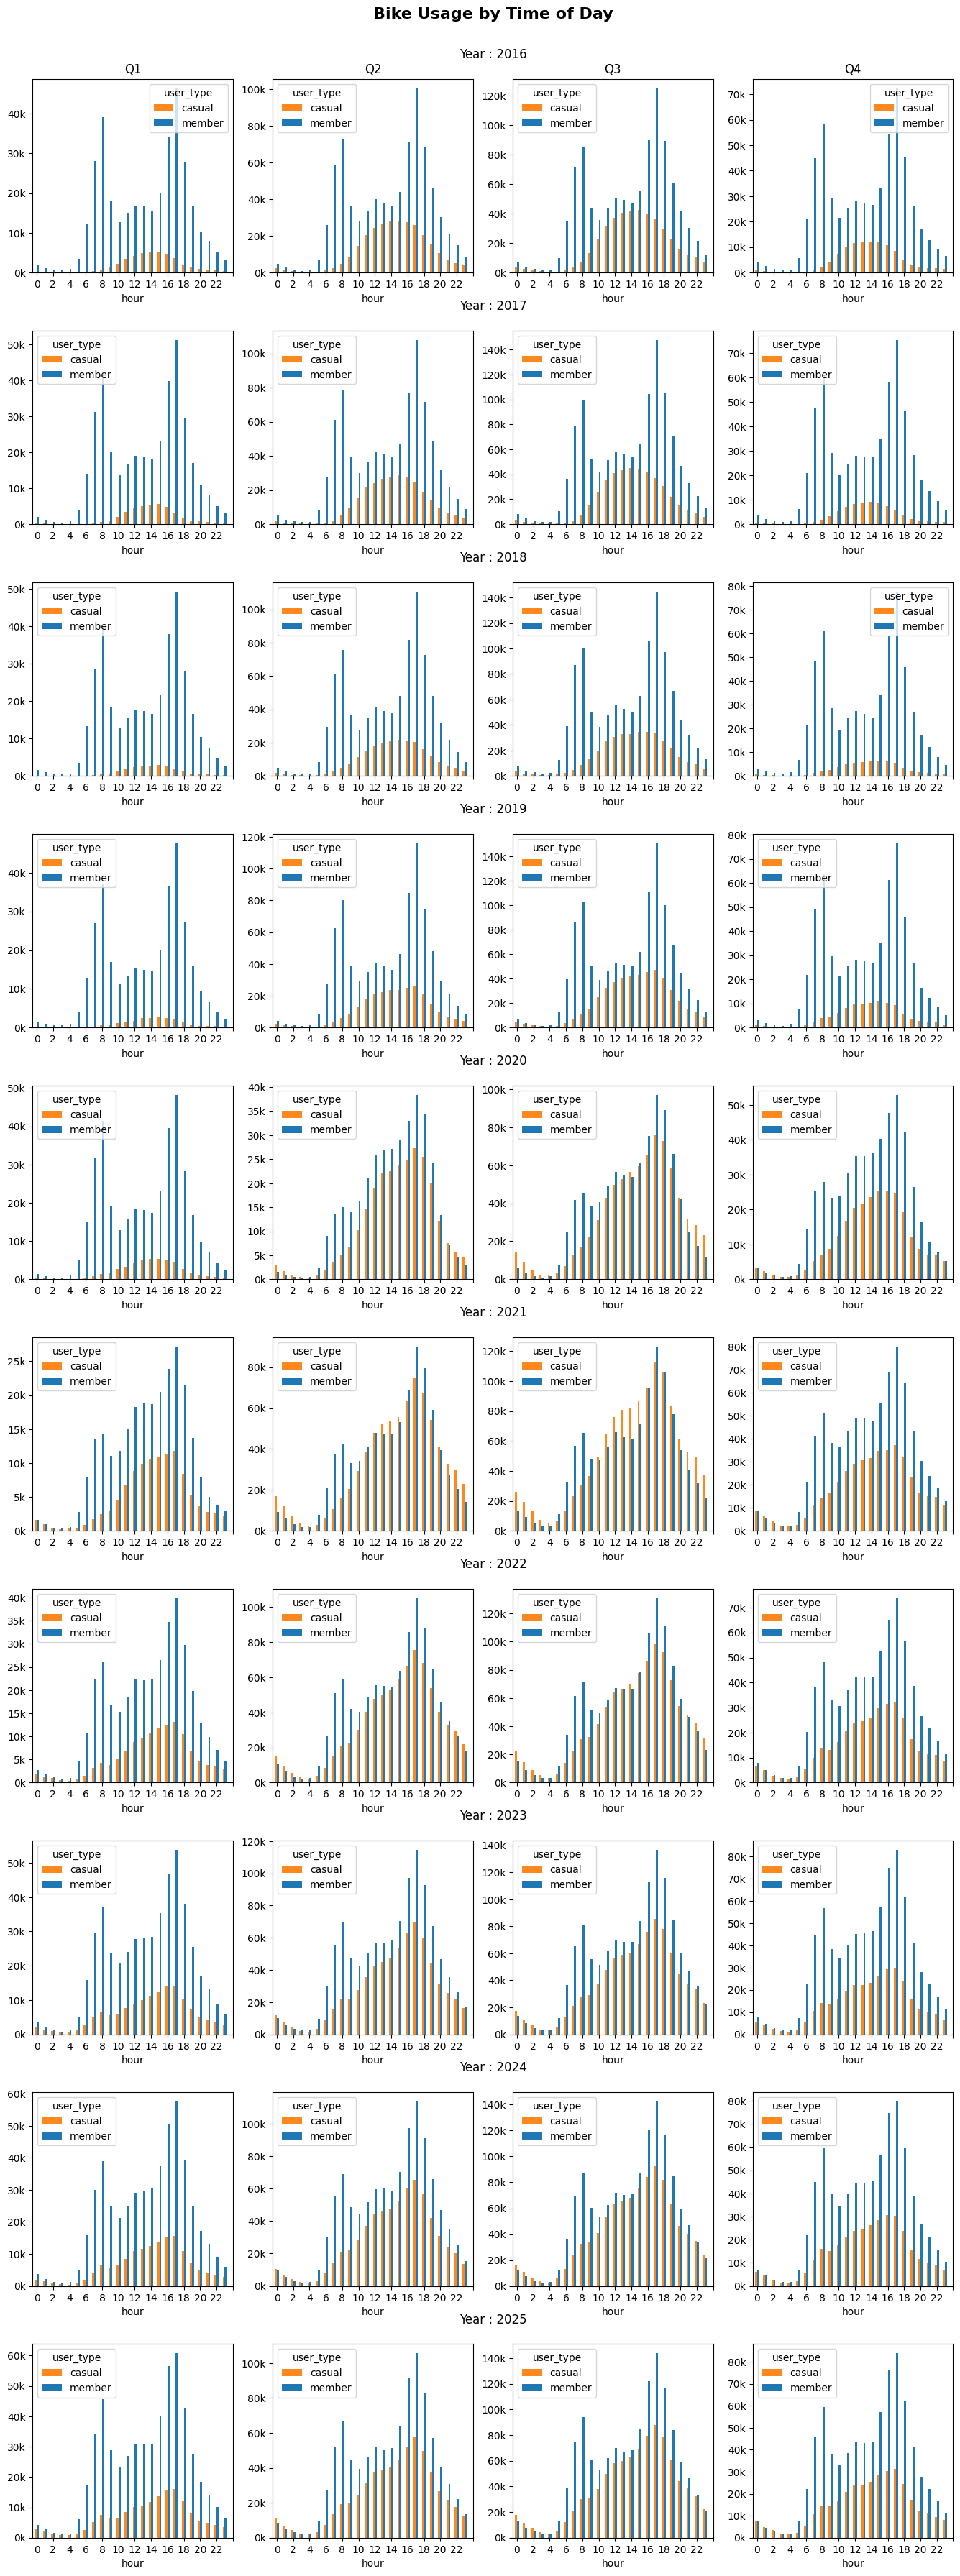

In [37]:
def draw_plot(r, c, axes):
    count_df = hour_dfs[c][r]
    count_df.plot(kind='bar', rot=0, color={'member':"#1f77b4", 'casual':"#FF881E"}, ax=axes[r, c])
    axes[r,c].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}k'))
    axes[r,c].set_xticks(range(0, 25, 2))

draw_subplots(draw_plot, "Bike Usage by Time of Day")

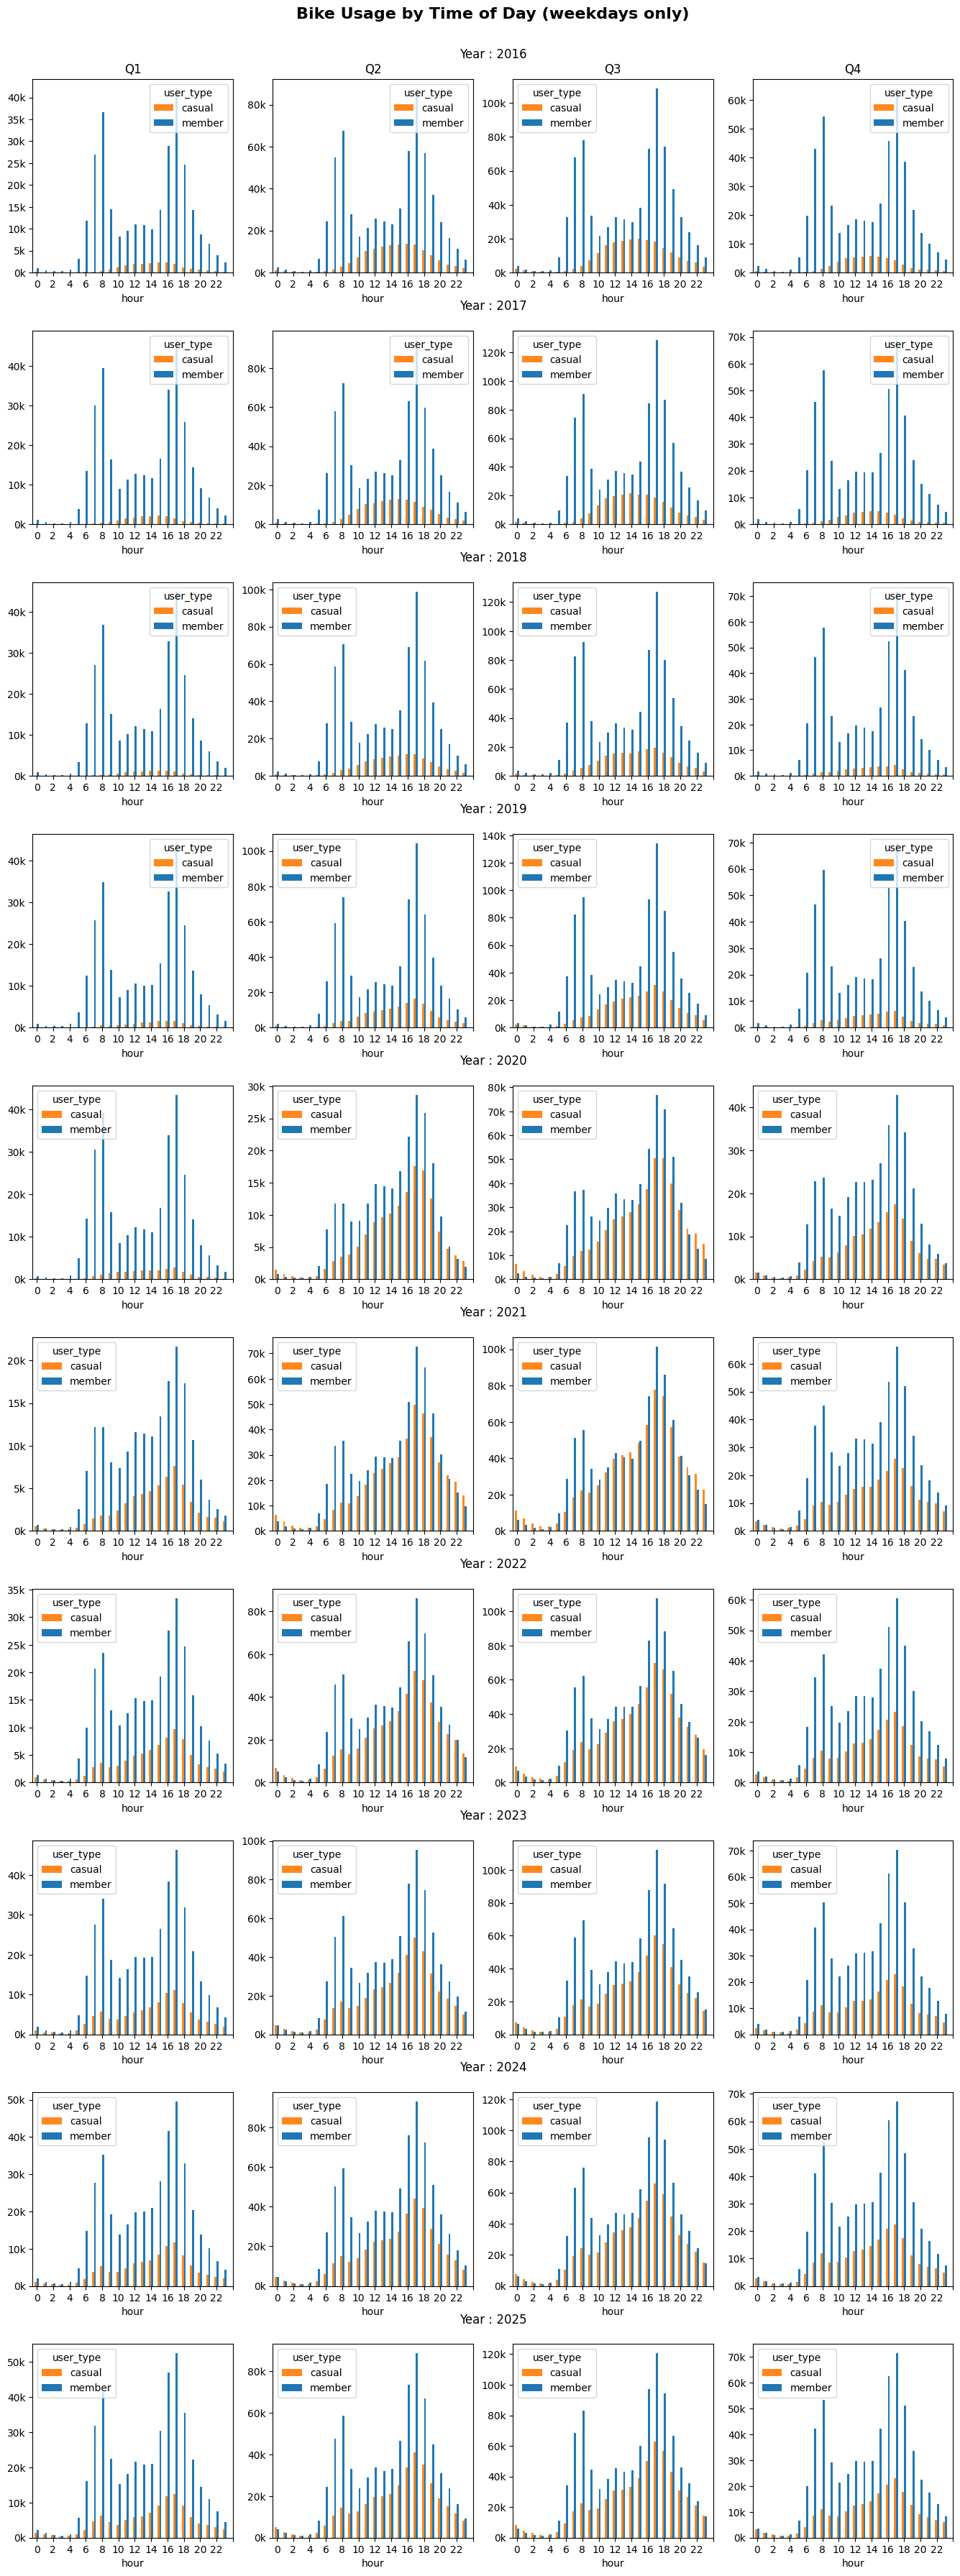

In [38]:
def draw_plot(r, c, axes):
    count_df = weekdayhour_dfs[c][r]
    count_df.plot(kind='bar', rot=0, color={'member':"#1f77b4", 'casual':"#FF881E"}, ax=axes[r, c])
    axes[r,c].yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}k'))
    axes[r,c].set_xticks(range(0, 25, 2))

draw_subplots(draw_plot, "Bike Usage by Time of Day (weekdays only)")

#### 3. Start Station Trends
Casual riders’ concentration at top stations dropped significantly after 2020:
* Pre‑2020: 25–30%
* Post‑2020: < 15%
  
This indicates more diverse usage patterns among casual riders.

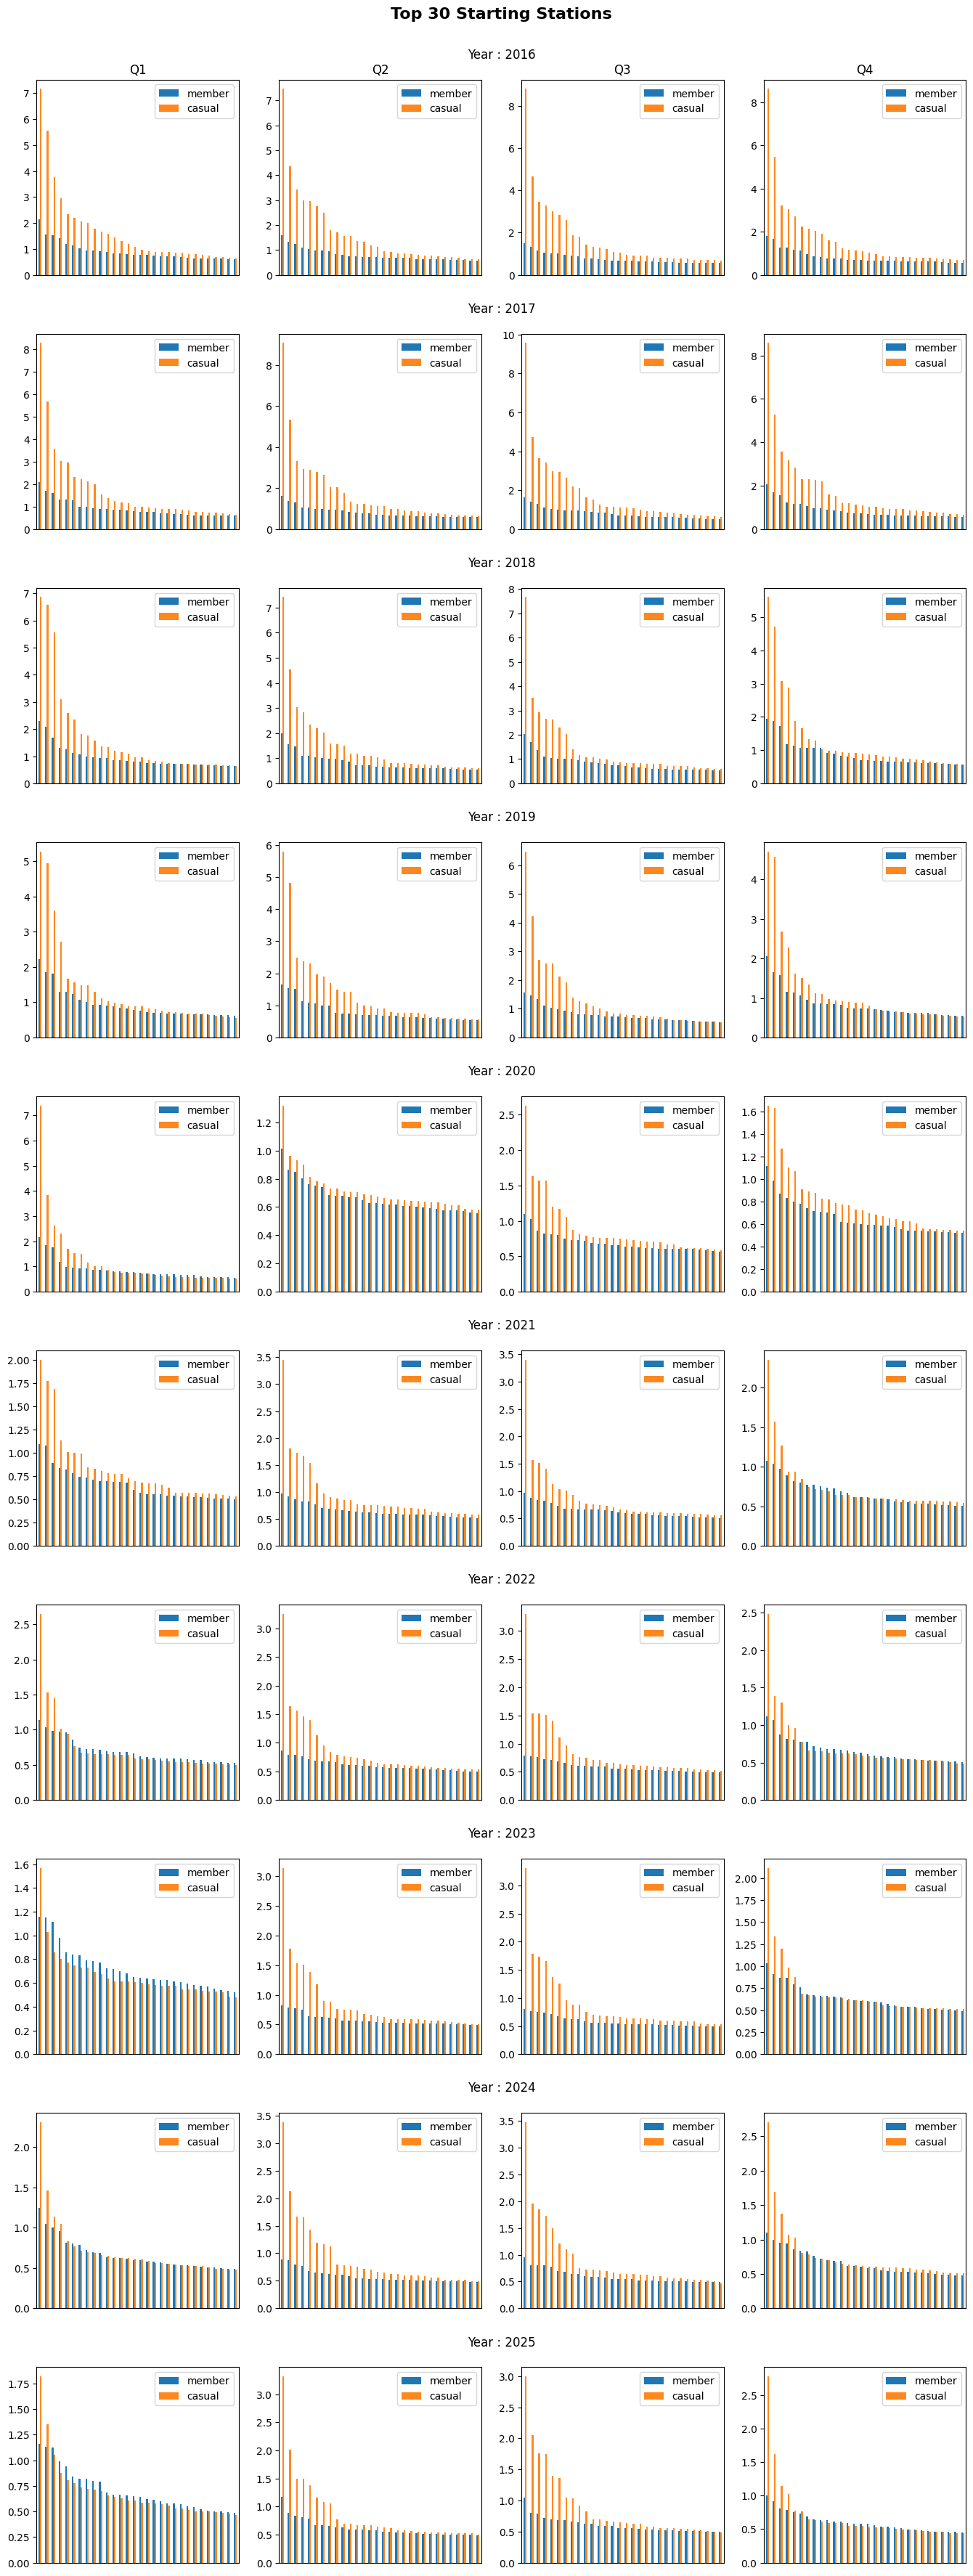

In [39]:
def draw_plot(r, c, axes):
    count_df = station_ranking_df[c][r][['member_p', 'casual_p']][:30]
    count_df.rename(columns={'member_p': 'member', 'casual_p': 'casual'}, inplace=True)
    count_df.plot(kind='bar', y=['member', 'casual'], color={'member':"#1f77b4", 'casual':"#FF881E"}, ax=axes[r, c]) 
    axes[r,c].set_xticks([])

draw_subplots(draw_plot, "Top 30 Starting Stations")

Looking at the "Top 30 Starting Stations" chart, the pattern mirrors that of the second quarter of 2016: annual members show a relatively even distribution, whereas casual riders exhibit a heavy concentration at the top 10 stations (excluding the 2020 pandemic period).  
However, a closer examination reveals significant differences compared to pre-2020 data; specifically, the share of trips originating from the top 10 stations for casual riders has clearly dropped by more than half.  
  
The line chart below illustrates the year-over-year changes in the proportion of trips originating from the top 10 stations; while annual members show little variation, casual riders exhibit a marked decline—dropping from a 25–30% share prior to 2020 to 15% or less thereafter.  
  
__This suggests that casual riders are utilizing the bike-sharing service in more diverse ways after year 2020, which could serve as an incentive for them to transition into annual members.__

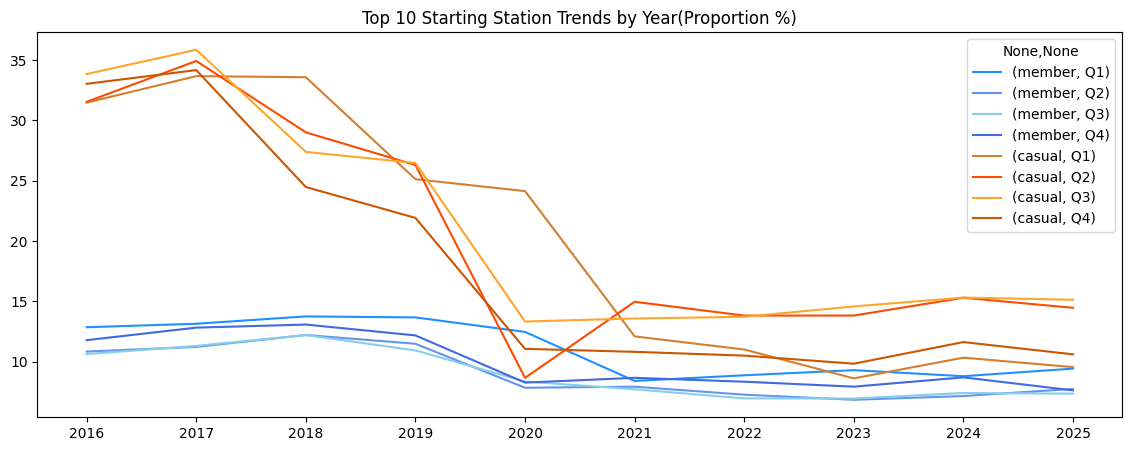

In [40]:
top10_rank_m = {'Q1': [], 'Q2' : [], 'Q3' : [], 'Q4' : []}
top10_rank_c = {'Q1': [], 'Q2' : [], 'Q3' : [], 'Q4' : []}

r = 0
for year in years:
    c = 0
    for q in ['Q1', 'Q2', 'Q3', 'Q4']:
        count_df = station_ranking_df[c][r][['member_p', 'casual_p']][:10]
        count_df
        top10_rank_m[q].append(count_df['member_p'].sum())
        top10_rank_c[q].append(count_df['casual_p'].sum())
        c += 1
    r += 1

top10_rank_m_df = pd.DataFrame(top10_rank_m, index=years)
top10_rank_c_df = pd.DataFrame(top10_rank_c, index=years)

top10_rank_df = pd.concat([top10_rank_m_df, top10_rank_c_df], keys=['member', 'casual'], axis=1)

ax = top10_rank_df.plot(color=['#1E90FF', '#6495ED', '#87CEEB', '#4169E1', '#D47E30', '#FC4C02', '#FFA52C', '#CC5500'], figsize=(14,5))
ax.set_title('Top 10 Starting Station Trends by Year(Proportion %)')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years) #, rotation=90)

plt.show()


#### 4. Trip Duration Trends
* Casual riders still take longer trips than members
* However, average duration for casual riders has steadily decreased since 2020
* The gap between member and casual duration has narrowed (from 3× in 2019 to 1.5× in 2025)

Long‑duration proportions (> 3 hours) increased slightly during the pandemic but have declined since.  
  
Operational implications:
* Casual riders’ longer trips and station clustering increase bike turnover pressure
* Converting casual riders to members could reduce operational costs

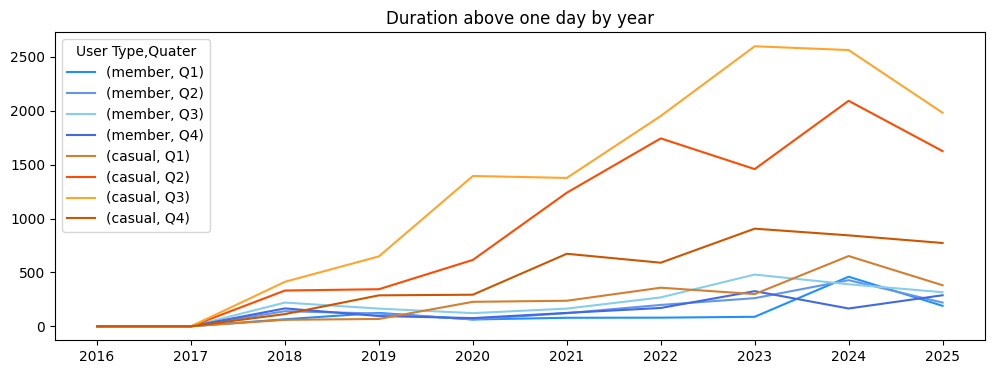

In [41]:
column1 = ['member', 'casual']
column2 = ['Q1', 'Q2', 'Q3', 'Q4']
columns = pd.MultiIndex.from_product([column1, column2], names=['member', 'casual'])

tmp_df = pd.DataFrame([x+y for x, y in zip([list(row) for row in zip(*oneday_m)], [list(row) for row in zip(*oneday_c)])], index=years, columns=columns).T
tmp_df.index.names = ['User Type', 'Quater']
#tmp_df.style.format(precision=0, thousands=",", decimal=".")
ax = tmp_df.T.plot(color=['#1E90FF', '#6495ED', '#87CEEB', '#4169E1', '#D47E30', '#FC4C02', '#FFA52C', '#CC5500'], 
                   figsize=(12,4), title="Duration above one day by year")
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years) #, rotation=90)
tmp_df.style.map(color_positive).format(precision=0, thousands=",", decimal=".")

Before beginning the detailed analysis, an examination of trips lasting 24 hours or longer—as shown in the table and line chart above—reveals that while these cases represent a small fraction of the total records, casual riders account for a significantly higher frequency. __This aligns with previous findings indicating that casual riders tend to have much longer trip durations.__  
  
The table and chart below show that data points with trip durations of less than zero appear with high frequency primarily in 2020—with few occurrences thereafter—and are distributed across both members and casual riders; consequently, they do not significantly impact the analysis results.

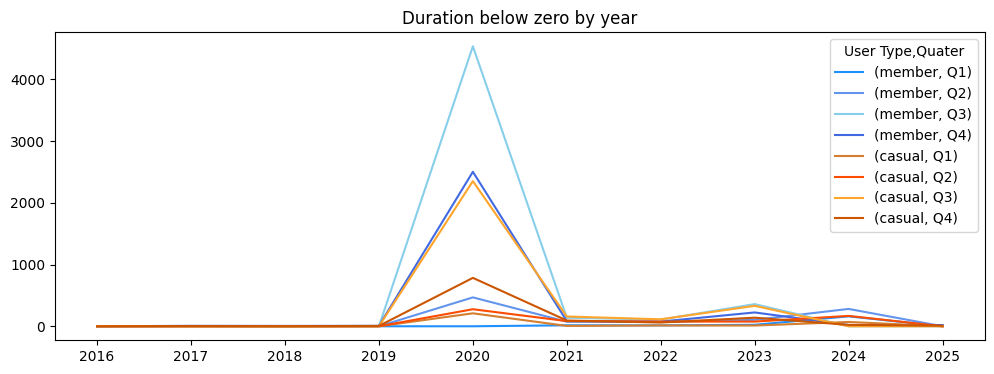

In [42]:
tmp_df = pd.DataFrame([x+y for x, y in zip([list(row) for row in zip(*zero_m)], [list(row) for row in zip(*zero_c)])], index=years, columns=columns).T
tmp_df.index.names = ['User Type', 'Quater']
#tmp_df.style.format(precision=0, thousands=",", decimal=".")
ax = tmp_df.T.plot(color=['#1E90FF', '#6495ED', '#87CEEB', '#4169E1', '#D47E30', '#FC4C02', '#FFA52C', '#CC5500'], 
                   figsize=(12,4), title="Duration below zero by year")
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years) #, rotation=90)
tmp_df.style.map(color_positive).format(precision=0, thousands=",", decimal=".")

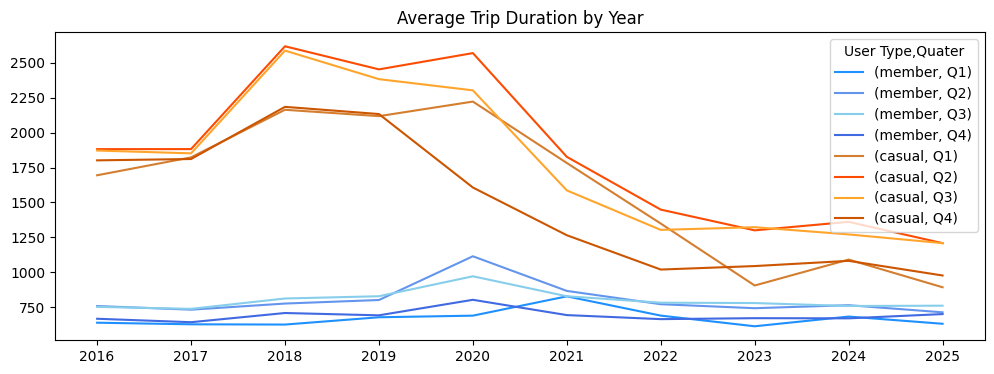

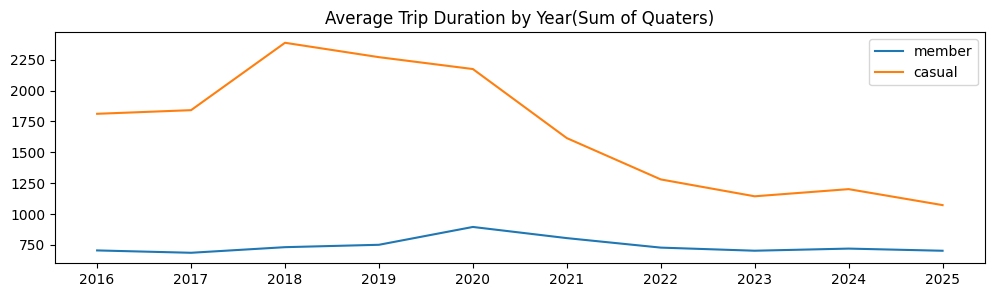

In [43]:
tmp_df = pd.DataFrame([x+y for x, y in zip([list(row) for row in zip(*mean_m)], [list(row) for row in zip(*mean_c)])], index=years, columns=columns).T
tmp_df.index.names = ['User Type', 'Quater']

ax = tmp_df.T.plot(color=['#1E90FF', '#6495ED', '#87CEEB', '#4169E1', '#D47E30', '#FC4C02', '#FFA52C', '#CC5500'], 
                   figsize=(12,4), title="Average Trip Duration by Year")
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years) #, rotation=90)
plt.show()

mean_df = pd.DataFrame({'member': [(a+b+c+d)/4 for a, b, c, d in zip(mean_m[0], mean_m[1], mean_m[2], mean_m[3])], 
                        'casual': [(a+b+c+d)/4 for a, b, c, d in zip(mean_c[0], mean_c[1], mean_c[2], mean_c[3])]}, index=years)

ax = mean_df.plot(kind='line', figsize=(12, 3), title="Average Trip Duration by Year(Sum of Quaters)")
#ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}k'))
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years) #, rotation=90)
plt.show()
mean_df = mean_df.T
mean_df.insert(loc=0, column='___Years', value=[" ", " "])

First, looking at the changes in "average trip duration over the years and quaters", the line charts above show that while there has been little change for annual members, the duration for casual riders has steadily declined since 2020.   
As shown in the table below, the average trip duration for casual riders was up to three times that of members in 2019, but by 2025, it was only 1.5 times as long.  

In [44]:
display(HTML(tmp_df.style.format(precision=0, thousands=",", decimal=".").to_html()))
print('')
display(HTML(mean_df.style.format(precision=0, thousands=",", decimal=".").to_html()))

,___Years,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
member,,705,686,731,751,895,805,728,702,720,702
casual,,"1,812","1,842","2,388","2,271","2,175","1,615","1,280","1,143","1,201","1,072"


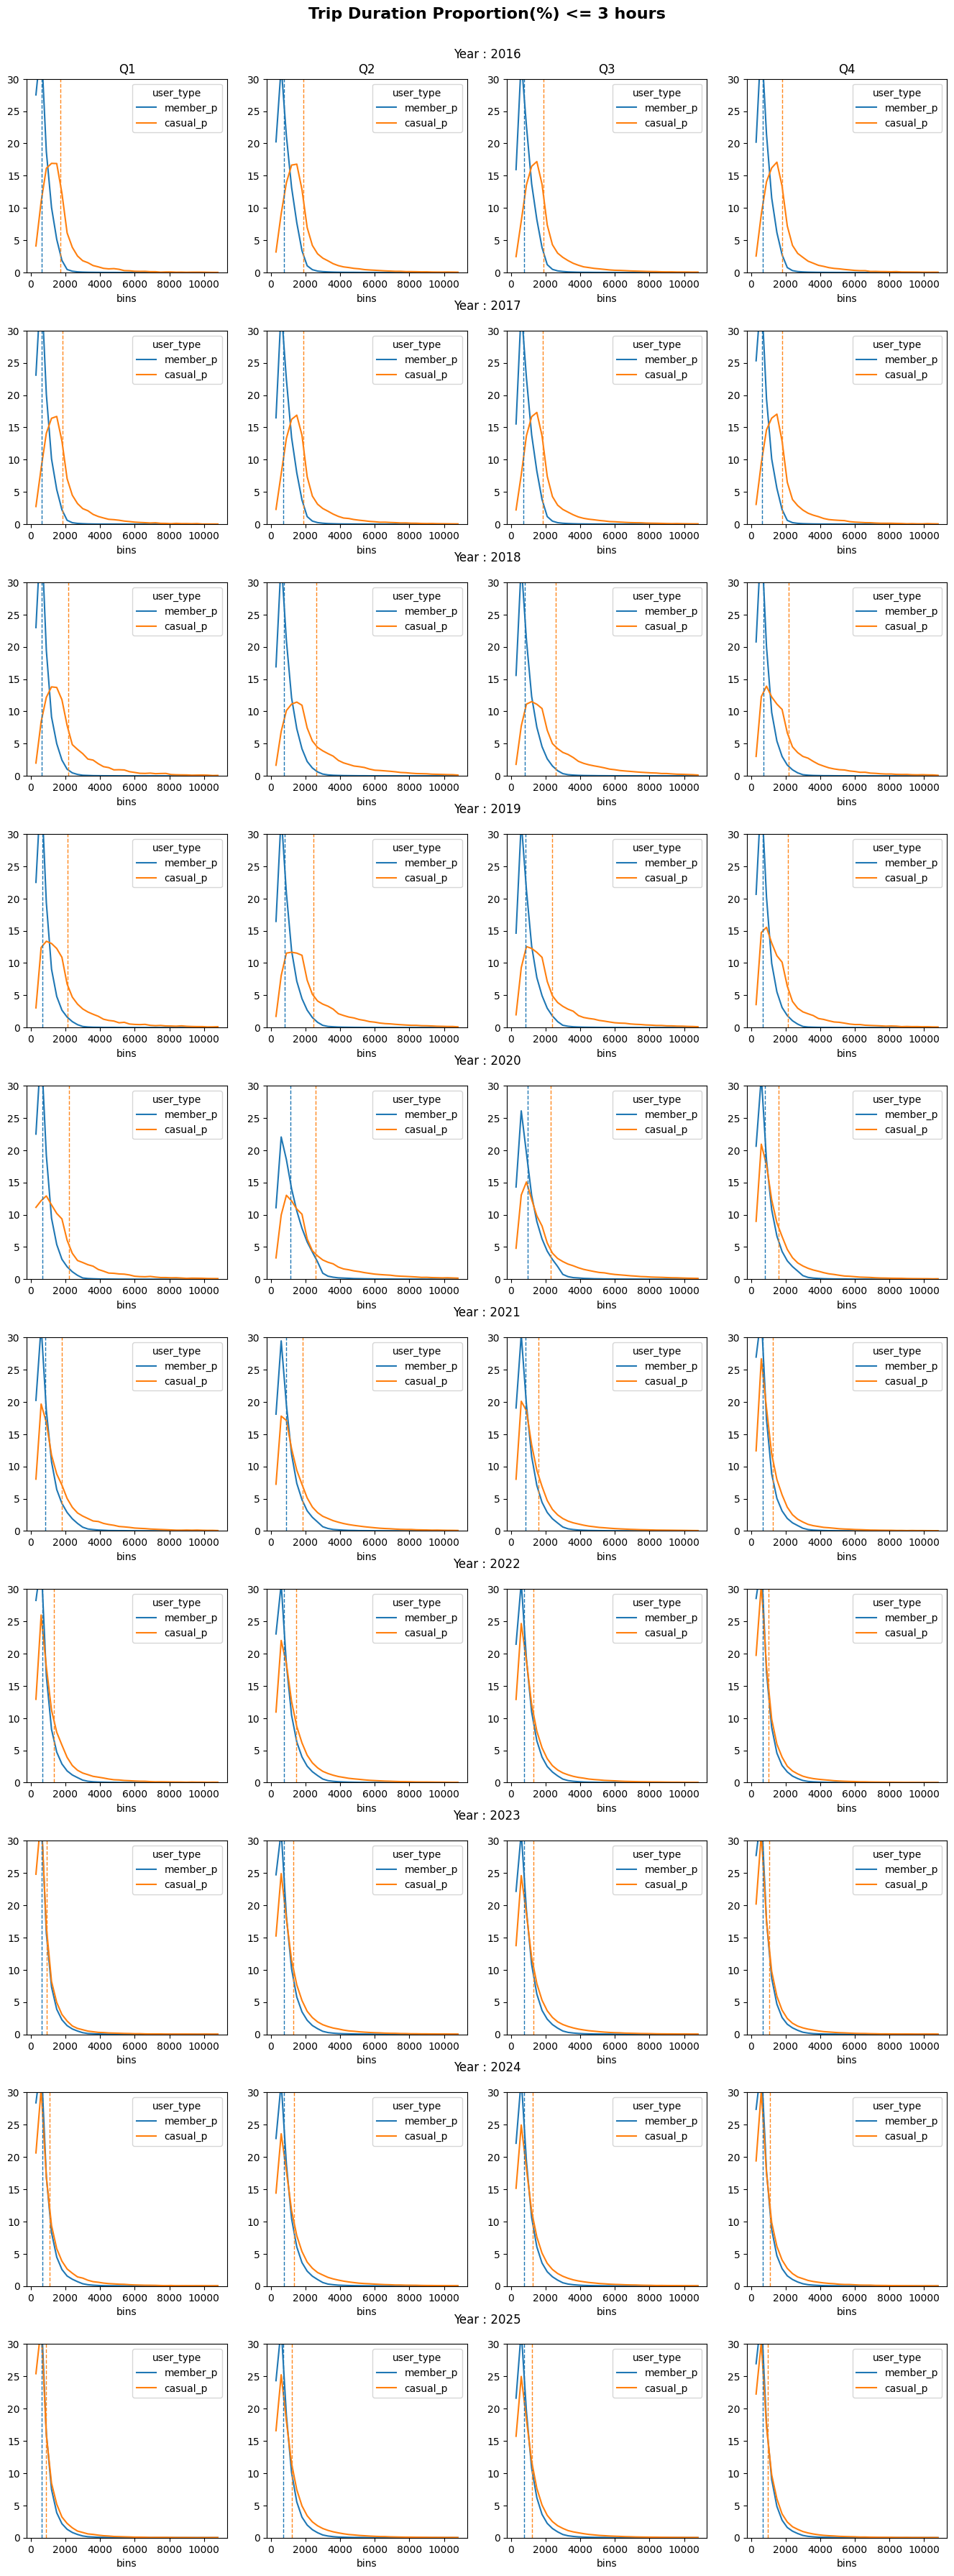

In [45]:
def draw_plot(r, c, axes):
    count_df = duration_dfs[c][r]
    count_df['bins'] = count_df['bins'].astype(int)
    count_df[count_df['bins'] <= 10800].plot(kind='line', x='bins', y=['member_p', 'casual_p'], ax=axes[r, c])
    axes[r, c].set_ylim(0, 30)

    # Add vertical line of average trip duration, blue:anual member, orange:casual rider
    axes[r, c].axvline(mean_m[c][r], color="#1f77b4", linestyle='--', linewidth=1)
    axes[r, c].axvline(mean_c[c][r], color='#FF881E', linestyle='--', linewidth=1)

draw_subplots(draw_plot, "Trip Duration Proportion(%) <= 3 hours") # under and equal to 10,800 seconds

According to the charts under "Trip Duration Proportion <= 10,800 Seconds" above, data from before 2020 shows a distinct difference in the distribution of trip durations between annual members and casual riders, as well as a significant gap in their average values ​​(indicated by the vertical lines).   
However, from 2020 onwards, this difference has largely disappeared, and the shape of graph looks similar. __This reflects a shift in behavior among "casual riders"—who previously tended to use the service for extended periods on a one-off basis—toward more varied usage patterns; this shift could serve as an incentive for them to convert to annual memberships.__

The distribution of trip durations exhibited a right-skewed, fat-tailed pattern; the charts "Trip Duration Proportion > 10,800" below illustrates the changes in this distribution. The overall proportion associated with this metric showed a gradual increase but has been declining since the end of the pandemic.  
However, casual riders still rent bicycles for longer periods compare to that of anual members, this fact can affect bicycle turnover rates. Combined with casual riders' tendency for bicycles to accumulate at specific stations, this necessitates stocking more bikes at stations, thereby potentially increasing fixed costs. Consequently, __policies aimed at converting casual riders into annual members could result in a reduction of the company's fixed costs.__

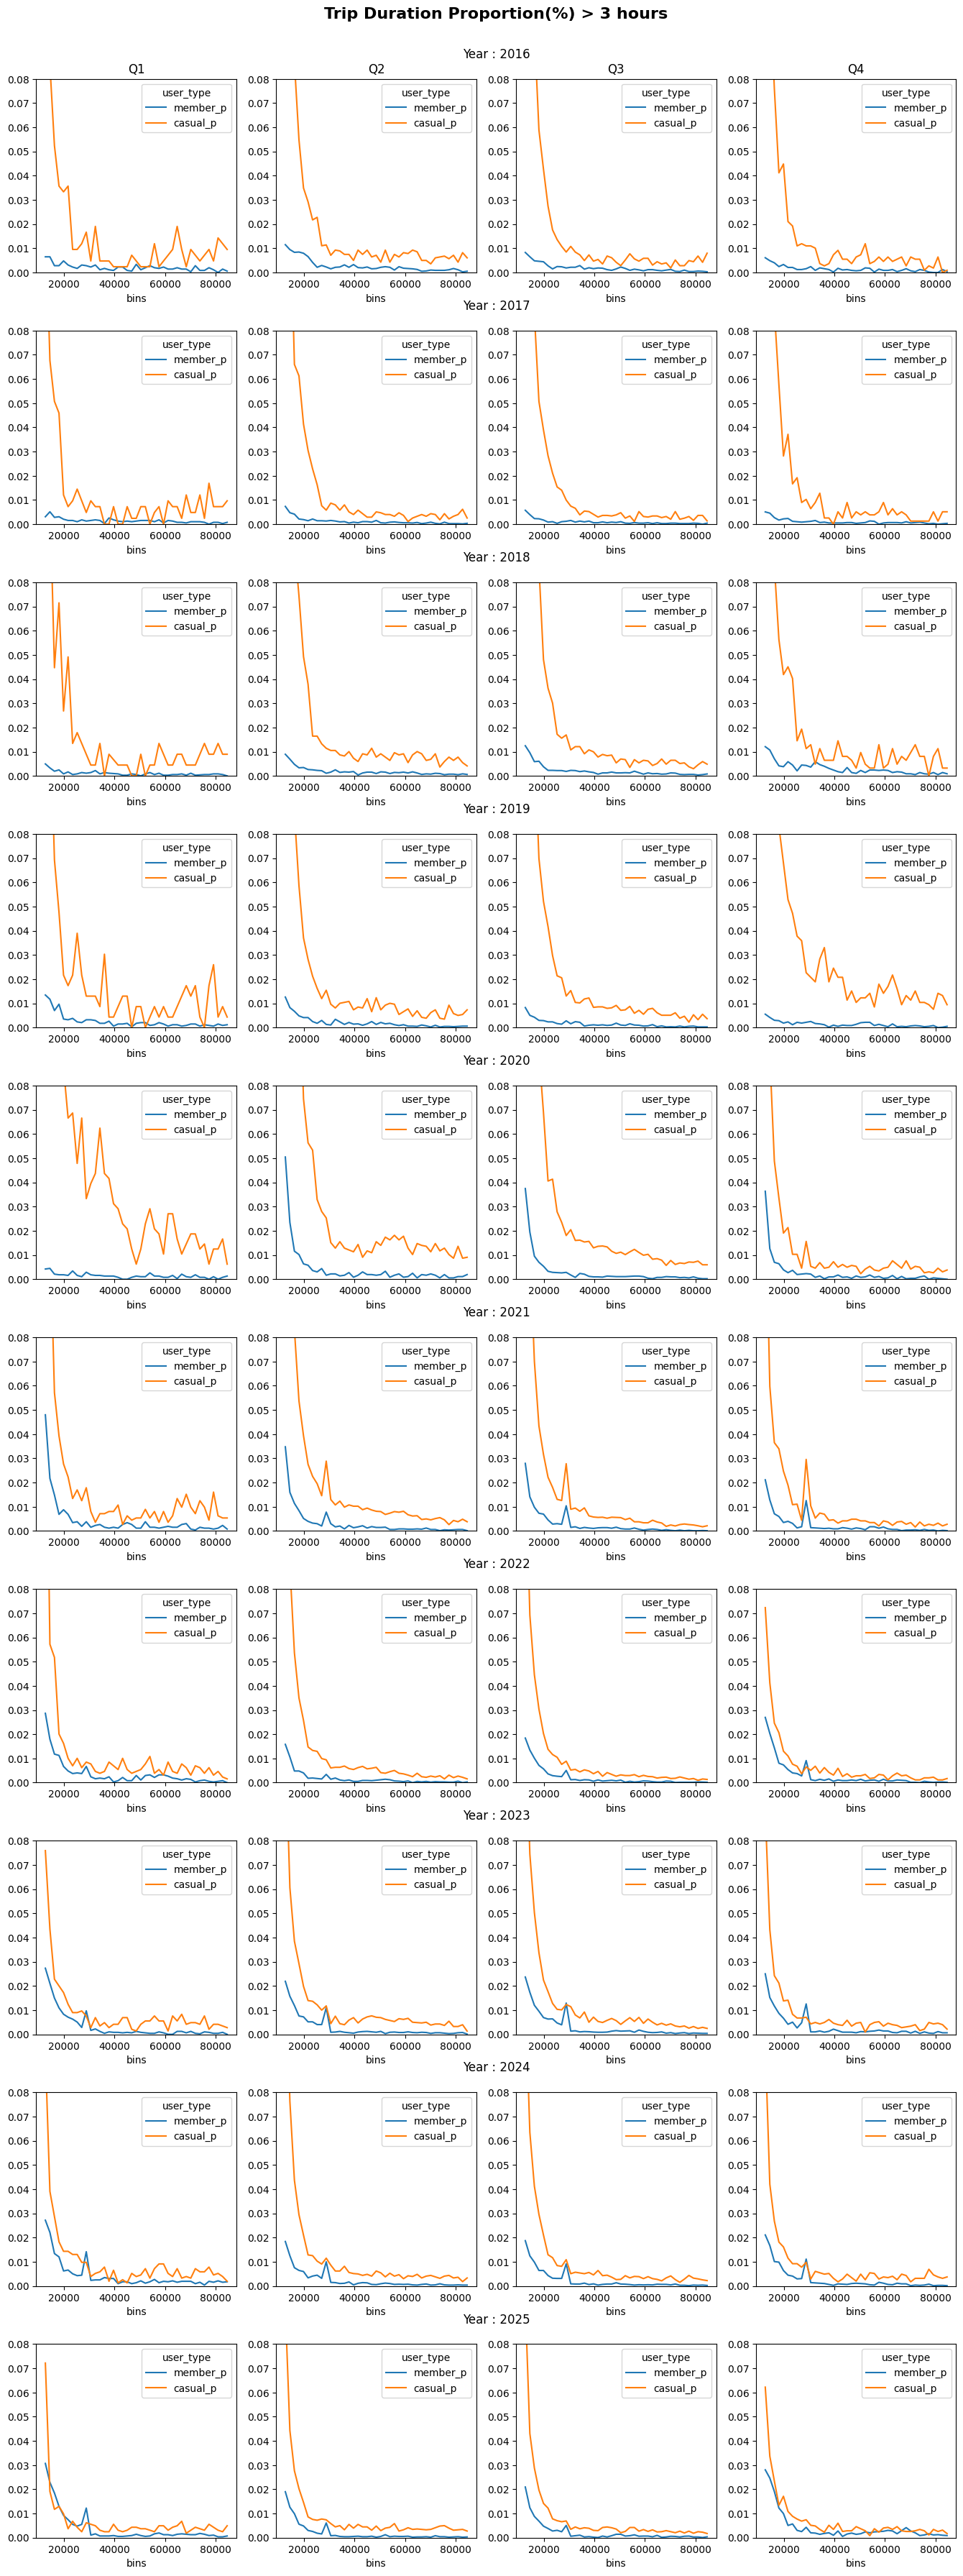

In [46]:
def draw_plot(r, c, axes):
    count_df = duration_dfs[c][r]
    count_df[count_df['bins'] > 10800].plot(kind='line', x='bins', y=['member_p', 'casual_p'], ax=axes[r, c])
    axes[r, c].set_ylim(0, 0.08)

draw_subplots(draw_plot, 'Trip Duration Proportion(%) > 3 hours')  # above 10,800 seconds

## 4. Conclusion
The comprehensive analysis of Cyclistic’s trip data reveals clear and actionable insights into how rider behavior has changed over the past decade. Annual members continue to demonstrate stable, commuting‑driven usage patterns, characterized by weekday trips, predictable peak‑hour activity, shorter ride durations, and broad station distribution. Casual riders, once primarily leisure users, have undergone a notable behavioral shift since 2020. Their weekday usage increased, their time‑of‑day patterns became more complex, and their station choices diversified. Trip durations also shortened, reducing the gap between casual and member behavior.

These changes suggest that a substantial portion of casual riders now use Cyclistic in ways similar to annual members. Combined with the rapid growth in casual ridership—particularly the 129% increase from 2019 to 2025—this creates a significant strategic opportunity. Converting these riders to annual memberships would not only increase long‑term revenue but also reduce operational strain caused by long-duration rides and station-level bike imbalances.

Overall, the findings strongly support the development of targeted marketing initiatives aimed at casual riders who exhibit commuting-like patterns or frequent usage. By leveraging these insights, Cyclistic can design effective, data-driven campaigns that align with evolving rider behavior and maximize future membership growth.